<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Андрей ! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Привет, Павел!</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

<span style="color: blue; font-size: 18px; font-weight: bold;">Комментарий ревьюера 2</span>

<span style="color: blue">Привет еще раз. Спасибо, за исправления. Оформление комментариев по работе сохраняется. Только обозначим, что это вторая итерация.</span> 

# https://github.com/2Myaka2/DataScience_projects

## работал в репозитории

# Название проекта и описание задачи

- Дайте название проекту, запишите его в блоке Markdown выше.
- Опишите, как вы поняли постановку задачи.
- Опишите данные для решения задачи.

# UrbanStay: прогноз отмены бронирований и оценка экономического эффекта

**Заказчик:** сеть отелей UrbanStay.

**Бизнес-задача.** Построить модель, которая по данным брони предсказывает вероятность
её отмены, чтобы отель заранее решал — искать нового постояльца или сохранить бронь.
Цена ошибки измеряется деньгами и **асимметрична**:
* **ложная отмена (FP)** — модель предсказала отмену, но гость приехал: компенсация,
  потеря лояльности, админиздержки (≈ 7 000 ₽ за случай);
* **пропущенная отмена (FN)** — модель не увидела отмену, номер простоял:
  упущенный доход (≈ 64 500 ₽ за случай).

**Цель проекта — не «идеально точная» модель, а финансово эффективная:** та, что
максимизирует прирост дохода (Incremental Revenue), снижает долю отмен и удерживает
загрузку отеля.

### Как я понял задачу

Невозможно построить безошибочную модель отмен, поэтому задача ставится прагматично:
оценить, **как работа модели влияет на прибыль сети**, и подтвердить, что внедрение
экономически выгодно. Качество измеряем тремя бизнес-показателями:

1. **Incremental Revenue (IR)** — прирост дохода от внедрения модели (главная метрика);
2. **Динамика доли отмен** бронирования (до / после);
3. **Динамика загрузки** отеля (до / после).

Целевые ориентиры заказчика:
* доля отмен после внедрения — около **10 %**;
* загрузка не должна упасть больше чем на **8 %**;
* относительный IR — не менее **50 %**.

### Данные

Данные лежат в БД PostgreSQL и выгружаются через SQLAlchemy. Используем две таблицы:
* `hotel_bookings` — брони (целевой признак отмены, даты, тариф, число гостей и т.д.);
* `hotel_reviews` — отзывы гостей (текст комментария, оценка, дата отзыва).

Таблицы связываются **темпорально**: к каждой брони подтягивается ближайший
*предыдущий* по дате отзыв клиента (`review_date` ≤ `booking_date`). Точную структуру
столбцов уточним сразу после загрузки.

## Перевод бизнес-задачи на язык машинного обучения

- Напишите, что конкретно будете делать с точки зрения Data Science: расскажите, какие модели и методы вы планируете применить для решения задачи.

## Перевод бизнес-задачи на язык машинного обучения

**Тип задачи.** Обучение с учителем, **бинарная классификация**: предсказываем
`y = 1` (бронь отменится) против `y = 0` (гость приедет). Модель выдаёт вероятность
отмены, по порогу переводим её в решение.

**Целевая метрика — Incremental Revenue.** Это не готовая метрика sklearn, а бизнес-функция
от матрицы ошибок:

> IR_после = (TP × PerRebooking) + (TN × AvgRev) − (FP × CostFP) − (FN × LostRev)

Поэтому в Optuna и при подборе порога мы будем оптимизировать **собственную функцию IR**,
а не accuracy/F1. Классические метрики (precision, recall, ROC-AUC) считаем как
вспомогательные — для контроля адекватности модели.

**Что планируем делать:**
1. Выгрузить и исследовать данные (EDA), почистить аномалии/пропуски/дубликаты.
2. Объединить брони с отзывами по правилу ближайшего предыдущего отзыва (`pd.merge_asof`).
3. Сконструировать признаки: ≥ 3 из данных брони (сезонность, лояльность, глубина брони…)
   + признаки из текстов отзывов через `TfidfVectorizer`.
4. Обучить ≥ 2 градиентных бустинга, разбив данные на train / калибровку / тест (60/20/20).
5. Подобрать гиперпараметры через Optuna (≥ 3 параметра), оптимизируя IR на кросс-валидации.
6. Откалибровать вероятности лучшей модели и найти **порог классификации под максимум IR**.
7. Проверить стабильность (confusion matrix + IR на калибровке и тесте), разобрать
   важность признаков (SHAP).
8. Посчитать экономический эффект и сформулировать выводы для бизнеса.

## Загрузка необходимых библиотек

- Загрузите всё, что планируете использовать для выполнения проекта.

In [1]:
%%writefile requirements.txt
numpy==1.26.4
pandas==2.2.3
scipy==1.13.1

scikit-learn==1.6.1

sqlalchemy==2.0.36
psycopg2-binary==2.9.10

catboost==1.2.7
lightgbm==4.5.0
xgboost==2.1.4

optuna==4.4.0
shap==0.46.0
nltk==3.9.1

matplotlib==3.9.4
seaborn==0.13.2
phik==0.12.4

joblib==1.5.3
ipykernel==6.29.5

Overwriting requirements.txt


In [2]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
! python --version

Python 3.12.3


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">~~matplotlib==3.10.8 не совместима с Python 3.9.5, самая новая matplotlib 3.9.4~~ </span>


</span><br><span style="color: purple; font-weight: bold">Заменил версию библиотеки</span>

<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

In [4]:
# Стандартная библиотека
import time
import warnings
from pathlib import Path

# Сторонние библиотеки
import numpy as np
import pandas as pd
import joblib
import re

from scipy import stats

# Подключение к базе данных
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Корреляционный анализ
import phik

# Препроцессинг
from sklearn.preprocessing import OneHotEncoder

# Работа в временными данными
from sklearn.model_selection import TimeSeriesSplit

# Векторизация текстов отзывов
from sklearn.feature_extraction.text import TfidfVectorizer

# Разбиение данных и кросс-валидация
from sklearn.model_selection import train_test_split, StratifiedKFold

# Калибровка вероятностей
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Метрики классификации (вспомогательные)
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)

# Модели градиентного бустинга
from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier
import lightgbm as lgb
from xgboost import XGBClassifier

# Интерпретация модели
import shap

# Подбор гиперпараметров
import optuna
from optuna.samplers import TPESampler

# Удаление стоп слов
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

russian_stopwords = set(stopwords.words("russian"))
print(f"Загружено русских стоп-слов: {len(russian_stopwords)}")

# Настройки отображения
warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")


# ---------- Константы проекта ----------

RANDOM_STATE = 42

TRAIN_SIZE = 0.60
CALIB_SIZE = 0.20
TEST_SIZE = 0.20

N_FOLDS = 3
VALID_SIZE = 2000          
N_TRIALS = 30              

TARGET = "is_canceled"

AVG_REV = 64_500           # средний доход от сдачи одного номера (AvgRev)
COST_FP = 7_000            # издержки ложного срабатывания, FP (CostFP)
LOST_REV = 64_500          # упущенный доход от отмены, FN (LostRev); = AvgRev
PER_REBOOKING = 45_000     # доход от повторной сдачи номера, TP (PerRebooking)

/home/andre/DS/DataScience_projects/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загружено русских стоп-слов: 151


[nltk_data] Downloading package stopwords to /home/andre/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, разделены на функциональные группы пустой строкой.</font>

## Этап 1: подготовка данных

### Загрузка данных

- Все данные о работе сети отелей хранятся в базе данных на сервере. Для работы с ними в Python используйте библиотеку SQLAlchemy, чтобы выгрузить данные SQL-запросом.

- Сделайте выводы о проделанной работе.

Параметры для подключения к данным PostgreSQL:

- **Хост:** rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net

- **База данных:** data-scientist-hotels

- **Порт:** 6432

- **Пользователь:** praktikum_student

- **Пароль:** Sdf4$2;d-d30pp

Названия нужных вам таблиц — `hotel_bookings` (таблица бронирований) и `hotel_reviews` (таблица отзывов).

In [5]:
DB_CONFIG = {
    "drivername": "postgresql+psycopg2",
    "host": "rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net",
    "port": 6432,
    "database": "data-scientist-hotels",
    "username": "praktikum_student",
    "password": "Sdf4$2;d-d30pp",
}

connection_url = URL.create(**DB_CONFIG)
engine = create_engine(connection_url)

In [6]:
DATA_DIR = Path("data")


def load_table(table_name, engine, data_dir=DATA_DIR):
    """Грузит таблицу из локального кэша, иначе из БД (с сохранением в кэш)."""
    local_path = data_dir / f"{table_name}.csv"

    if local_path.exists():
        df = pd.read_csv(local_path)
        source = f"локального кэша {local_path}"
    else:
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", engine)
        df.to_csv(local_path, index=False)
        source = f"БД (сохранено в {local_path})"

    print(f"{table_name}: загружена из {source} — "
          f"{df.shape[0]:,} строк, {df.shape[1]} столбцов")
    return df


bookings = load_table("hotel_bookings", engine)
reviews = load_table("hotel_reviews", engine)

hotel_bookings: загружена из локального кэша data/hotel_bookings.csv — 35,341 строк, 17 столбцов
hotel_reviews: загружена из локального кэша data/hotel_reviews.csv — 25,177 строк, 5 столбцов


In [7]:
def show_df_info(name, df, head_rows=5):
    print("=" * 100)
    print(f"Датасет: {name}")
    print("=" * 100)

    print("\nИнформация о типах данных:")
    df.info()

    print("\nПервые строки:")
    display(df.head(head_rows))

    print("\nСводка по столбцам:")
    columns_info = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null_values": df.notna().sum().values,
        "missing_values": df.isna().sum().values,
        "missing_percent": (df.isna().mean() * 100).round(2).values,
        "unique_values": df.nunique(dropna=False).values,
    })

    display(columns_info)

    print("\nПропуски:")
    missing_info = columns_info[columns_info["missing_values"] > 0].copy()

    if missing_info.empty:
        print("Пропусков не обнаружено.")
    else:
        display(
            missing_info[
                ["column", "missing_values", "missing_percent"]
            ].sort_values("missing_percent", ascending=False)
        )

    print("\nКоличество явных дубликатов:")
    duplicated_count = df.duplicated().sum()
    duplicated_percent = duplicated_count / len(df) * 100 if len(df) > 0 else 0
    print(f"{duplicated_count} строк ({duplicated_percent:.2f}%)")

    numeric_columns = df.select_dtypes(include=np.number).columns

    if len(numeric_columns) > 0:
        print("\nОписательная статистика по числовым признакам:")
        display(df[numeric_columns].describe().T)

    categorical_columns = df.select_dtypes(include=["object", "category", "bool"]).columns

    low_cardinality_info = []

    for col in categorical_columns:
        unique_count = df[col].nunique(dropna=False)

        if unique_count <= 20:
            values = df[col].dropna().unique().tolist()
            low_cardinality_info.append({
                "column": col,
                "unique_values_count": unique_count,
                "values": values,
            })

    if low_cardinality_info:
        print("\nКатегориальные признаки с небольшим числом уникальных значений:")
        display(pd.DataFrame(low_cardinality_info))

    print("\n")

    return {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_total": df.isna().sum().sum(),
        "duplicated_rows": duplicated_count,
        "memory_mb": df.memory_usage(deep=True).sum() / 1024**2,
    }

In [8]:
datasets = {"hotel_bookings": bookings, 
            "hotel_reviews": reviews}
datasets_summary = []

for name, df in datasets.items():
    summary = show_df_info(name, df)
    datasets_summary.append(summary)

datasets_summary = pd.DataFrame(datasets_summary)

print("=" * 100)
print("Общая сводка по исходным таблицам")
print("=" * 100)

display(datasets_summary)

Датасет: hotel_bookings

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  object 
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  object 
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  object 
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1



Сводка по столбцам:


,column,dtype,non_null_values,missing_values,missing_percent,unique_values
0,booking_id,object,35341,0,0.0,30733
1,booking_date,object,35341,0,0.0,2445
2,sales_channel,object,35341,0,0.0,3
3,adult_count,int64,35341,0,0.0,6
4,child_count,int64,35341,0,0.0,3
5,returning_customer,bool,35341,0,0.0,2
6,previous_cancellations,int64,35341,0,0.0,6
7,previous_no_shows,int64,35341,0,0.0,6
8,booking_status,object,35341,0,0.0,2
9,booking_value,float64,35341,0,0.0,1766



Пропуски:
Пропусков не обнаружено.

Количество явных дубликатов:
4608 строк (13.04%)

Описательная статистика по числовым признакам:


...

,column,dtype,non_null_values,missing_values,missing_percent,unique_values
0,customer_id,object,25177,0,0.0,13429
1,booking_id,object,25177,0,0.0,21883
2,review_date,object,25177,0,0.0,2514
3,stay_rating,int64,25177,0,0.0,4
4,review_text,object,25177,0,0.0,14153



Пропуски:
Пропусков не обнаружено.

Количество явных дубликатов:
0 строк (0.00%)

Описательная статистика по числовым признакам:


,count,mean,std,min,25%,50%,75%,max
stay_rating,25177.0,3.395321,0.541434,2.0,3.0,3.0,4.0,5.0




Общая сводка по исходным таблицам


,dataset,rows,columns,missing_total,duplicated_rows,memory_mb
0,hotel_bookings,35341,17,0,4608,21.825379
1,hotel_reviews,25177,5,0,0,14.381883


<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> Важно показать всю фразу в поле `review_text` для анализа.</font>
```python
# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)
```

In [9]:
# Прицельная диагностика подозрительных столбцов hotel_bookings

print("Баланс целевой переменной booking_status:")
display(bookings["booking_status"].value_counts(dropna=False))
display(bookings["booking_status"].value_counts(normalize=True).round(3))

print("\nadult_count — распределение значений (max=300 подозрителен):")
display(bookings["adult_count"].value_counts().sort_index())

print("\nbooking_value — нулевые / околонулевые брони:")
print(f"ровно 0:       {(bookings['booking_value'] == 0).sum()}")
print(f"меньше 1000:   {(bookings['booking_value'] < 1000).sum()}")

print("\nКатегориальные столбцы — проверка на неявные дубликаты:")
for col in ["sales_channel", "meal_plan", "room_type"]:
    print(f"\n{col}:")
    display(bookings[col].value_counts(dropna=False))

Баланс целевой переменной booking_status:


booking_status
нет_отказа     25177
отказ_брони    10164
Name: count, dtype: int64

booking_status
нет_отказа     0.712
отказ_брони    0.288
Name: proportion, dtype: float64


adult_count — распределение значений (max=300 подозрителен):


adult_count
1      13361
2      13102
3       6727
100      884
200      872
300      395
Name: count, dtype: int64

...

sales_channel
офлайн_бронирование           12040
корпоративное_бронирование    11747
онлайн_бронирование           11554
Name: count, dtype: int64


meal_plan:


meal_plan
тип_питания_1    27182
не выбран         4426
тип_питания_2     3219
не выбрант         507
тип_питания_3        7
Name: count, dtype: int64


room_type:


room_type
тип_1    27197
тип_4     6070
тип_6      959
тип_2      658
тип_5      272
тип_7      175
тип_3       10
Name: count, dtype: int64

In [10]:
# Природа дубликатов: полные строки vs дубли по booking_id
print(f"Полных дубликатов строк:   {bookings.duplicated().sum()}")
print(f"Дубликатов по booking_id:  {bookings.duplicated(subset='booking_id').sum()}")
print(f"Уникальных booking_id:     {bookings['booking_id'].nunique()} из {len(bookings)}")

Полных дубликатов строк:   4608
Дубликатов по booking_id:  4608
Уникальных booking_id:     30733 из 35341


In [11]:
# Диапазоны дат и связь таблиц — пригодится для темпорального объединения
for df, col, name in [(bookings, "booking_date", "bookings.booking_date"),
                      (reviews, "review_date", "reviews.review_date")]:
    d = pd.to_datetime(df[col])
    print(f"{name}: с {d.min().date()} по {d.max().date()}")

print("\nСвязь bookings ↔ reviews:")
common = set(bookings["booking_id"]) & set(reviews["booking_id"])
print(f"общих booking_id:            {len(common)}")
print(f"booking_id в reviews:        {reviews['booking_id'].nunique()}")
print(f"макс. отзывов у клиента:     {reviews['customer_id'].value_counts().max()}")

bookings.booking_date: с 2017-01-01 по 2025-10-22


reviews.review_date: с 2017-01-17 по 2026-03-03

Связь bookings ↔ reviews:
общих booking_id:            21883
booking_id в reviews:        21883
макс. отзывов у клиента:     8


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [12]:
# Работаем на копии без полных дубликатов
bk = bookings.drop_duplicates().reset_index(drop=True)
print(f"После удаления дубликатов: {len(bk):,} строк")

anom_adults = bk["adult_count"].isin([100, 200, 300])
zero_value = bk["booking_value"] == 0

print(f"\nadult_count ∈ {{100,200,300}}: {anom_adults.sum()} строк "
      f"({anom_adults.mean()*100:.1f}%)")
print(f"booking_value == 0:        {zero_value.sum()} строк "
      f"({zero_value.mean()*100:.1f}%)")

print("\nДоля статусов среди аномального adult_count vs нормального:")
display(bk.groupby(anom_adults)["booking_status"]
          .value_counts(normalize=True).round(3))

print("\nДоля статусов среди нулевой стоимости vs нормальной:")
display(bk.groupby(zero_value)["booking_status"]
          .value_counts(normalize=True).round(3))

print(f"\nСтрок с обеими аномалиями сразу: {(anom_adults & zero_value).sum()}")

После удаления дубликатов: 30,733 строк

adult_count ∈ {100,200,300}: 2151 строк (7.0%)
booking_value == 0:        1229 строк (4.0%)

Доля статусов среди аномального adult_count vs нормального:


adult_count  booking_status
False        нет_отказа        0.712
             отказ_брони       0.288
True         нет_отказа        0.706
             отказ_брони       0.294
Name: proportion, dtype: float64


Доля статусов среди нулевой стоимости vs нормальной:


booking_value  booking_status
False          нет_отказа        0.712
               отказ_брони       0.288
True           нет_отказа        0.709
               отказ_брони       0.291
Name: proportion, dtype: float64


Строк с обеими аномалиями сразу: 97


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Отлично! Удалили явные дубликаты.</font>

In [13]:
def clean_bookings(df):
    """Очистка hotel_bookings: дубликаты, неявные дубли, аномалии, кодировка таргета."""
    df = df.copy()

    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Удалено дубликатов:                {before - len(df):>5} → {len(df):,} строк")

    # Неявный дубликат: 'не выбрант' — опечатка 
    df["meal_plan"] = df["meal_plan"].replace("не выбрант", "не выбран")

    # Невозможные значения adult_count (100/200/300) — битые данные
    anom = df["adult_count"].isin([100, 200, 300])
    print(f"Удалено аномалий adult_count:      {anom.sum():>5} → {len(df) - anom.sum():,} строк")
    
    # adult_count: значения 100/200/300 — ошибка записи 
    anom_mask = df["adult_count"].isin([100, 200, 300])
    df.loc[anom_mask, "adult_count"] = df.loc[anom_mask, "adult_count"] // 100
    print(f"Исправлено adult_count (÷100):     {anom_mask.sum():>5} строк сохранено")

    # booking_value == 0 — некачественные данные
    zero_mask = df["booking_value"] == 0
    df = df[~zero_mask].reset_index(drop=True)
    print(f"Удалено нулевой стоимости:         {zero_mask.sum():>5} → {len(df):,} строк")

    df[TARGET] = (df["booking_status"] == "отказ_брони").astype(int)
    df = df.drop(columns=["booking_status"])

    return df


bookings_clean = clean_bookings(bookings)

print(f"\nИтоговый баланс таргета ({TARGET}):")
display(bookings_clean[TARGET].value_counts(normalize=True).round(3))

Удалено дубликатов:                 4608 → 30,733 строк
Удалено аномалий adult_count:       2151 → 28,582 строк
Исправлено adult_count (÷100):      2151 строк сохранено
Удалено нулевой стоимости:          1229 → 29,504 строк

Итоговый баланс таргета (is_canceled):


is_canceled
0    0.712
1    0.288
Name: proportion, dtype: float64

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Отлично, поправили опечатку в meal_plan!</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>~~Обрати внимание на группы в adult_count.\
Здесь явная ошибка записи. Нужно убрать нули у аномальных значений. 300 → 3~~</font>

</span><br><span style="color: purple; font-weight: bold">Поправил</span>

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> Верно! Здесь явная ошибка записи. Нужно убрать нули у аномальных значений.</font>

### Вывод по предобработке и первичному анализу данных

**Объём и структура.** Из БД выгружены две таблицы: `hotel_bookings` (35 341 строка,
17 столбцов) и `hotel_reviews` (25 177 строк, 5 столбцов). Пропусков нет ни в одной.
Целевой признак — `booking_status` в таблице броней.

**Дубликаты.** В `hotel_bookings` обнаружено 4 608 полных дубликатов (13 %). Проверка
показала, что множество полных дубликатов строк и дубликатов по `booking_id` совпадает:
строки с одинаковым `booking_id` идентичны по всем 17 столбцам. Поскольку `booking_id` —
уникальный ключ брони, это техническое задвоение при выгрузке без новой информации.
Удалили → осталось 30 733 уникальные брони. В `hotel_reviews` дубликатов нет.

**Аномалии в `adult_count`.** Помимо реалистичных значений 1–3, признак содержит значения
100, 200 и 300 (2 151 строка, 7 %). Это не реальное число гостей, а ошибка записи —
лишний ноль. Гипотеза подтверждается тремя независимыми проверками: распределение
аномальных значений после деления на 100 совпадает с распределением нормальных 1/2/3
(41/40/18 % против 40/40/20 %), средняя стоимость брони идентична (≈ 60–62 тыс. ₽), доля
отмен та же (29.4 % против 28.7 %). Поэтому значения исправлены делением на 100
(`100→1, 200→2, 300→3`), а строки сохранены.

**Неявные дубликаты в `meal_plan`.** Категория `не выбрант` (507) — опечатка `не выбран`
(4 426). Схлопнули в одно значение. Сверхредкие категории (`тип_питания_3` — 7 строк,
`room_type` `тип_3` — 10 строк) оставили без изменений.

**Нулевая стоимость брони.** `booking_value == 0` встречается у 1 229 строк (4 %). При этом
у таких броней есть реальные ночи проживания (от 1 до 21, в среднем 8.6), а стоимость
размещения не может быть нулевой. Это указывает на некачественные данные, а не на
легитимную категорию, поэтому строки удалены.

**Целевая переменная.** `booking_status` закодирован в бинарный `is_canceled`
(`отказ_брони → 1`, `нет_отказа → 0`). После очистки осталось **29 504 брони**, баланс
классов **71.2 % / 28.8 %** — умеренный дисбаланс. Учтём это при выборе метрик (ROC-AUC
вместо accuracy).

**Связь таблиц (задел на объединение).** У броней и отзывов 21 883 общих `booking_id`;
`customer_id` присутствует только в `reviews` (до 8 отзывов на клиента). Это определит
логику темпорального объединения в следующем блоке.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>~~Есть много нулевых значений стоимости.
 Причём и у тех кто отменил бронь, и у тех, кто не отменял.
 В данных не должно так быть. Стоимость номера всегда есть. Поэтому, считаем,
 что данные строки по бронированию не качественные. И лучше от них сразу избавиться.~~</font>

</span><br><span style="color: purple; font-weight: bold">Понял Принял Поправил!</span>

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span> ✔️\
<font color='green'> Убрали непонятные данные с нулевой стоимостью.</font>

### Исследовательский анализ данных и предобработка

- Проведите EDA, используя один из следующих инструментов на ваш выбор:

    - библиотеку pandas;
    - SQL-запросы.
    
- EDA должен включать:
    - аналитическое исследование;
    - графическое исследование для количественных данных и для категориальных данных.

- Сделайте выводы о выбросах, пропусках, дубликатах и других аномалиях  в каждой таблице.
- Проведите необходимую предобработку данных.

### Исследовательский анализ данных и предобработка

Аналитическую часть EDA и базовую предобработку мы выполнили выше, на шаге загрузки
данных:

1. **Загрузка** — обе таблицы выгружены из PostgreSQL через SQLAlchemy.
2. **Первичный осмотр** — `head()`, `info()`, `describe()`: изучены типы, диапазоны и
   распределения статистик; выявлены аномалии (`adult_count` = 100/200/300,
   `booking_value` = 0).
3. **Дубликаты и пропуски** — пропусков нет; в `hotel_bookings` найдено и удалено
   4 608 полных дубликатов (совпадают с дублями по ключу `booking_id`).
4. **Фильтрация и предобработка** — удалены битые значения `adult_count`, исправлен
   неявный дубликат `meal_plan` (`не выбрант` → `не выбран`), целевой признак
   `booking_status` закодирован в бинарный `is_canceled` (баланс 71.2 % / 28.8 %).
   Решение по нулевой стоимости (`booking_value` = 0) обосновано кросс-таблицей с
   таргетом — строки сохранены как легитимная категория.

Ниже выполним **графический и статистический разбор**: распределения всех признаков
(гистограммы для непрерывных, countplot для дискретных и категориальных, боксплоты),
проверку нормальности (Q-Q плоты + статистический тест), корреляционный анализ
с обсуждением мультиколлинеарности и развёрнутый финальный вывод по EDA.

In [14]:
CONTINUOUS_FEATURES = [
    "booking_value",
    "days_until_checkin",
    "weekday_nights",
    "weekend_nights",
]

DISCRETE_FEATURES = [
    "adult_count",
    "child_count",
    "previous_cancellations",
    "previous_no_shows",
    "customer_special_requests",
]

CATEGORICAL_FEATURES = [
    "sales_channel",
    "returning_customer",
    "meal_plan",
    "parking_included",
    "room_type",
]

print(f"Непрерывных признаков:    {len(CONTINUOUS_FEATURES)}")
print(f"Дискретных признаков:     {len(DISCRETE_FEATURES)}")
print(f"Категориальных признаков: {len(CATEGORICAL_FEATURES)}")
print(f"Всего признаков (без id/дат/таргета): "
      f"{len(CONTINUOUS_FEATURES) + len(DISCRETE_FEATURES) + len(CATEGORICAL_FEATURES)}")

Непрерывных признаков:    4
Дискретных признаков:     5
Категориальных признаков: 5
Всего признаков (без id/дат/таргета): 14


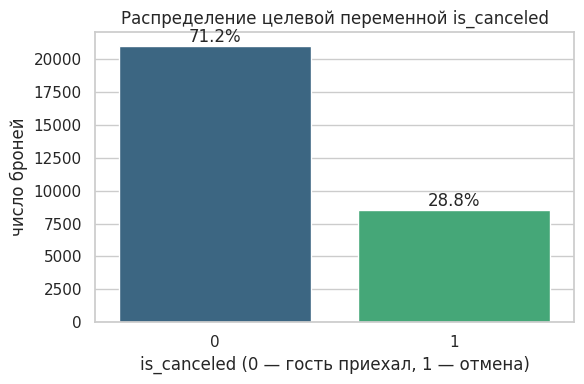

Баланс классов:


is_canceled
0    0.712
1    0.288
Name: proportion, dtype: float64

In [15]:
# Распределение целевой переменной
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=bookings_clean[TARGET], ax=ax, palette="viridis")
ax.set_title("Распределение целевой переменной is_canceled")
ax.set_xlabel("is_canceled (0 — гость приехал, 1 — отмена)")
ax.set_ylabel("число броней")

# Подписи долей над столбцами
total = len(bookings_clean)
for p in ax.patches:
    ax.annotate(f"{p.get_height() / total:.1%}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

print("Баланс классов:")
display(bookings_clean[TARGET].value_counts(normalize=True).round(3))

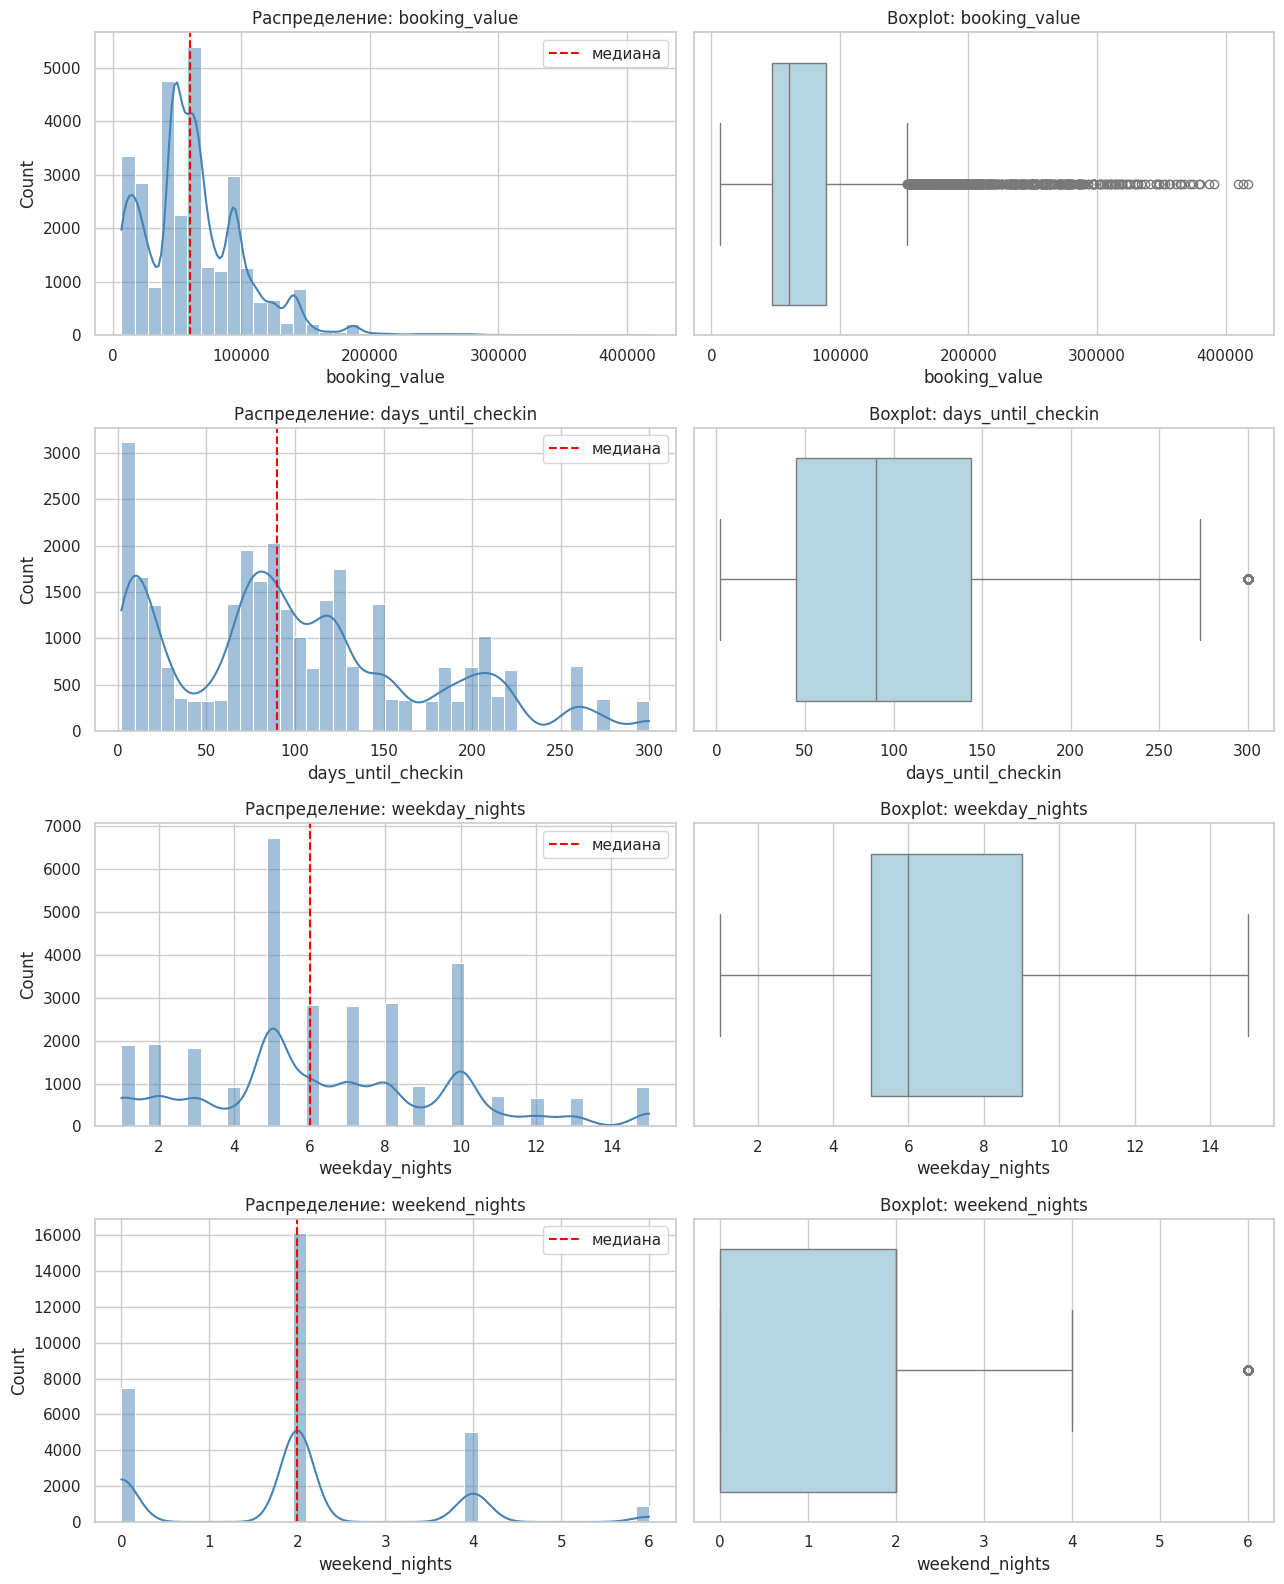

In [16]:
# Непрерывные признаки
fig, axes = plt.subplots(len(CONTINUOUS_FEATURES), 2,
                         figsize=(13, 4 * len(CONTINUOUS_FEATURES)))

for i, col in enumerate(CONTINUOUS_FEATURES):
    sns.histplot(bookings_clean[col], bins=40, kde=True,
                 ax=axes[i, 0], color="steelblue")
    axes[i, 0].axvline(bookings_clean[col].median(), color="red",
                       linestyle="--", label="медиана")
    axes[i, 0].set_title(f"Распределение: {col}")
    axes[i, 0].legend()

    sns.boxplot(x=bookings_clean[col], ax=axes[i, 1], color="lightblue")
    axes[i, 1].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

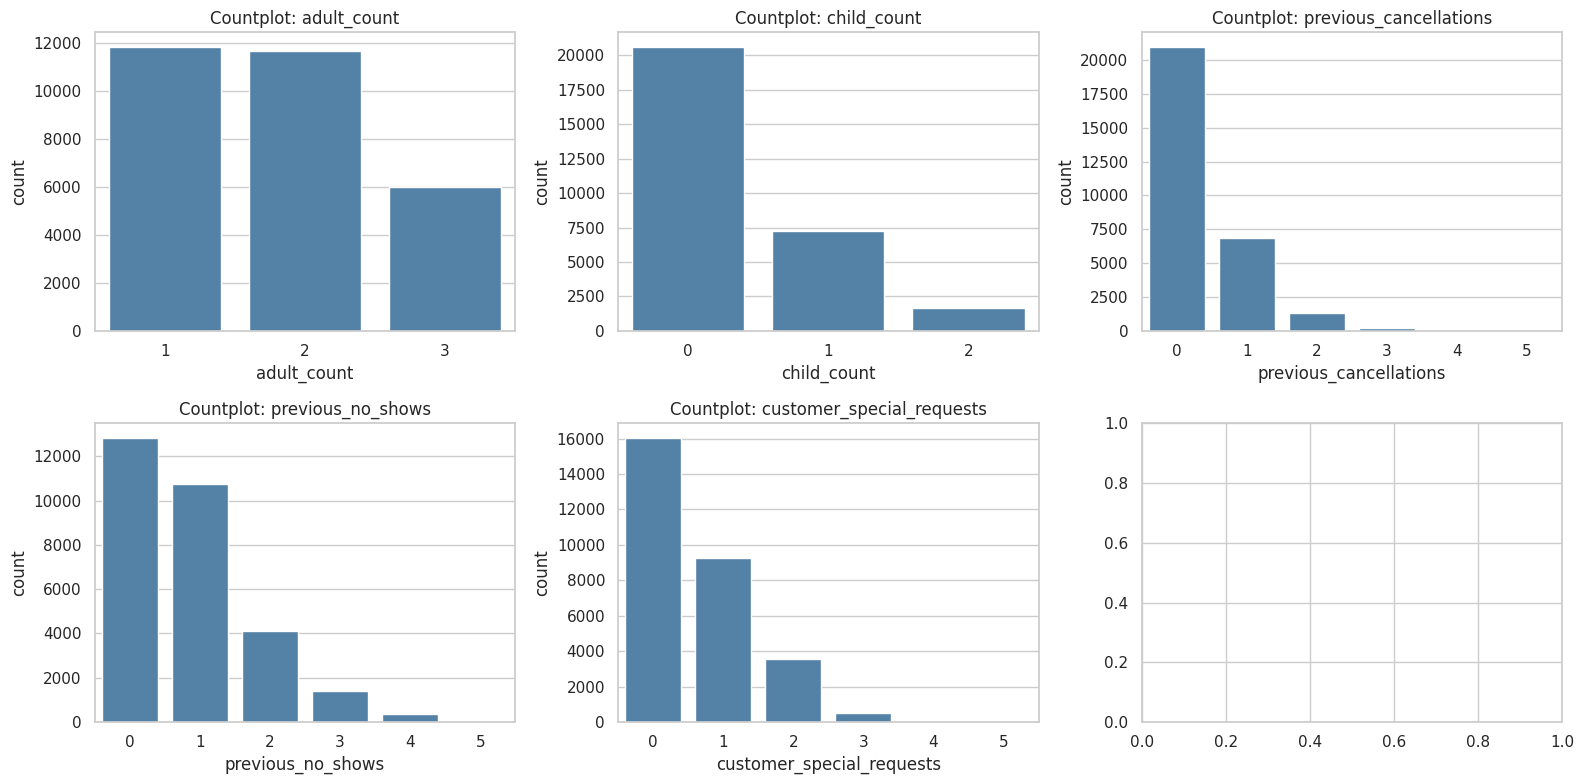

In [17]:
# Дискретные
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, DISCRETE_FEATURES):
    sns.countplot(x=bookings_clean[col], ax=ax, color="steelblue")
    ax.set_title(f"Countplot: {col}")

plt.tight_layout()
plt.show()

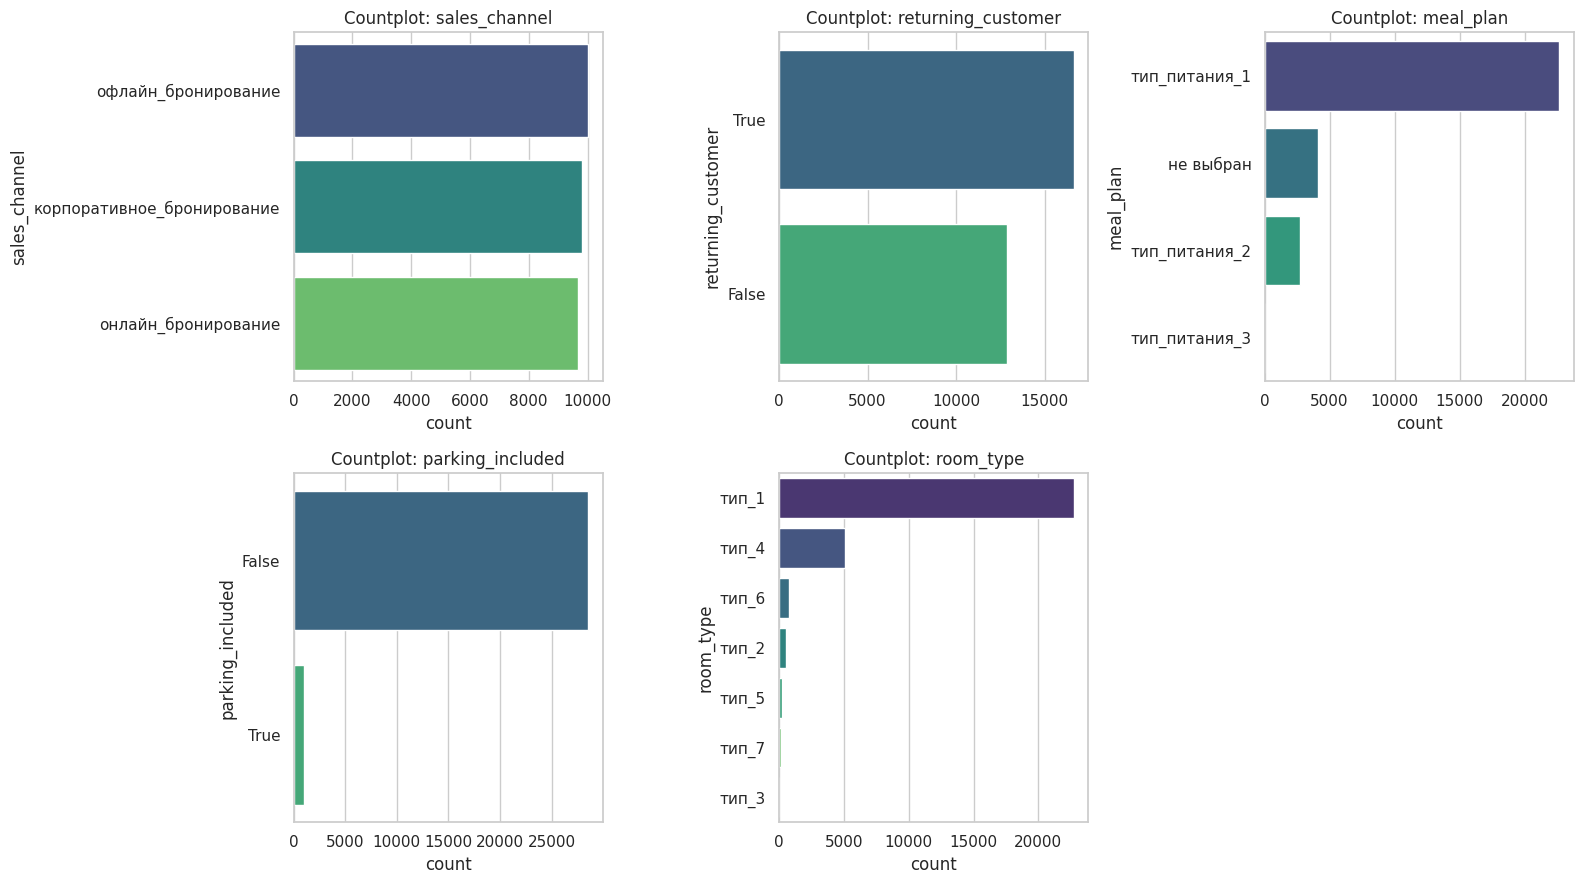

In [18]:
# Категориальные признаки
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, CATEGORICAL_FEATURES):
    order = bookings_clean[col].value_counts().index
    sns.countplot(y=bookings_clean[col], order=order, ax=ax, palette="viridis")
    ax.set_title(f"Countplot: {col}")

for ax in axes[len(CATEGORICAL_FEATURES):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

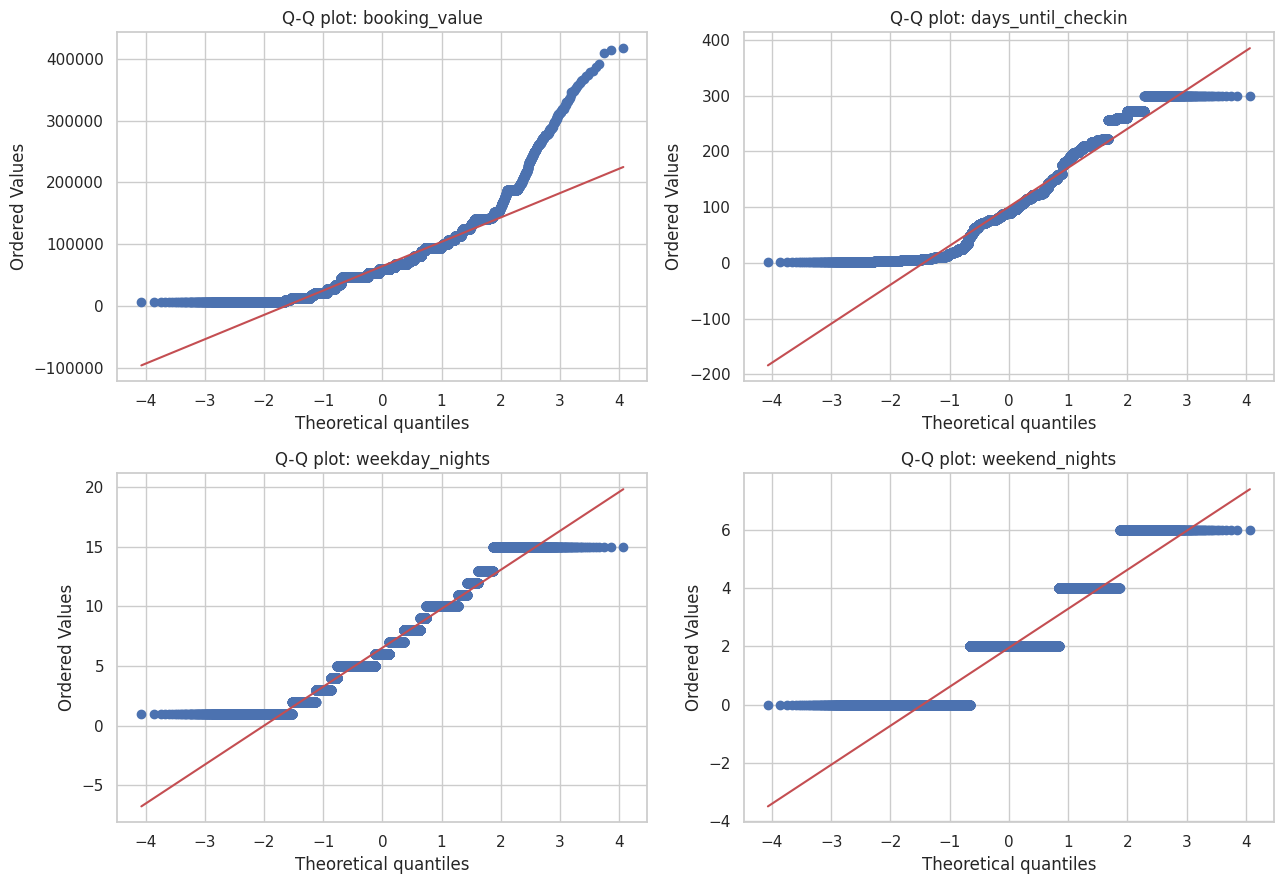

Тест нормальности Д'Агостино (H0: распределение нормальное):


,признак,skew,kurtosis,p_value,нормальное
0,booking_value,1.5727,5.6656,0.0,нет
1,days_until_checkin,0.6103,-0.2137,0.0,нет
2,weekday_nights,0.4251,-0.1950,0.0,нет
3,weekend_nights,0.4953,0.1302,0.0,нет


In [19]:
# Проверка нормальности непрерывных признаков: Q-Q плоты + тест Д'Агостино
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, col in zip(axes, CONTINUOUS_FEATURES):
    stats.probplot(bookings_clean[col], dist="norm", plot=ax)
    ax.set_title(f"Q-Q plot: {col}")

plt.tight_layout()
plt.show()

normality = []
for col in CONTINUOUS_FEATURES:
    stat, p = stats.normaltest(bookings_clean[col])
    normality.append({
        "признак": col,
        "skew": bookings_clean[col].skew(),
        "kurtosis": bookings_clean[col].kurtosis(),
        "p_value": p,
        "нормальное": "да" if p > 0.05 else "нет",
    })

print("Тест нормальности Д'Агостино (H0: распределение нормальное):")
display(pd.DataFrame(normality).round(4))

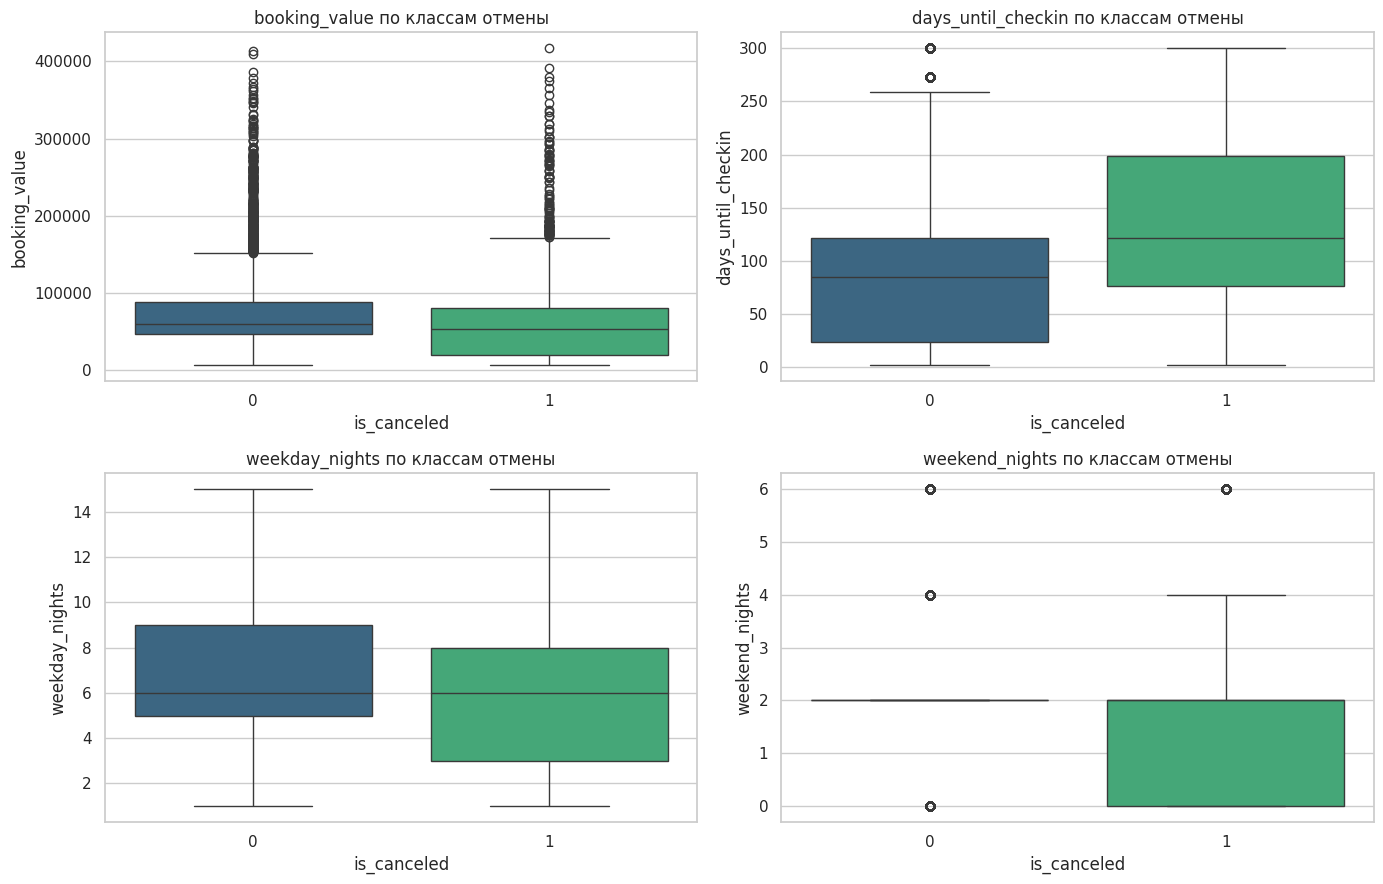

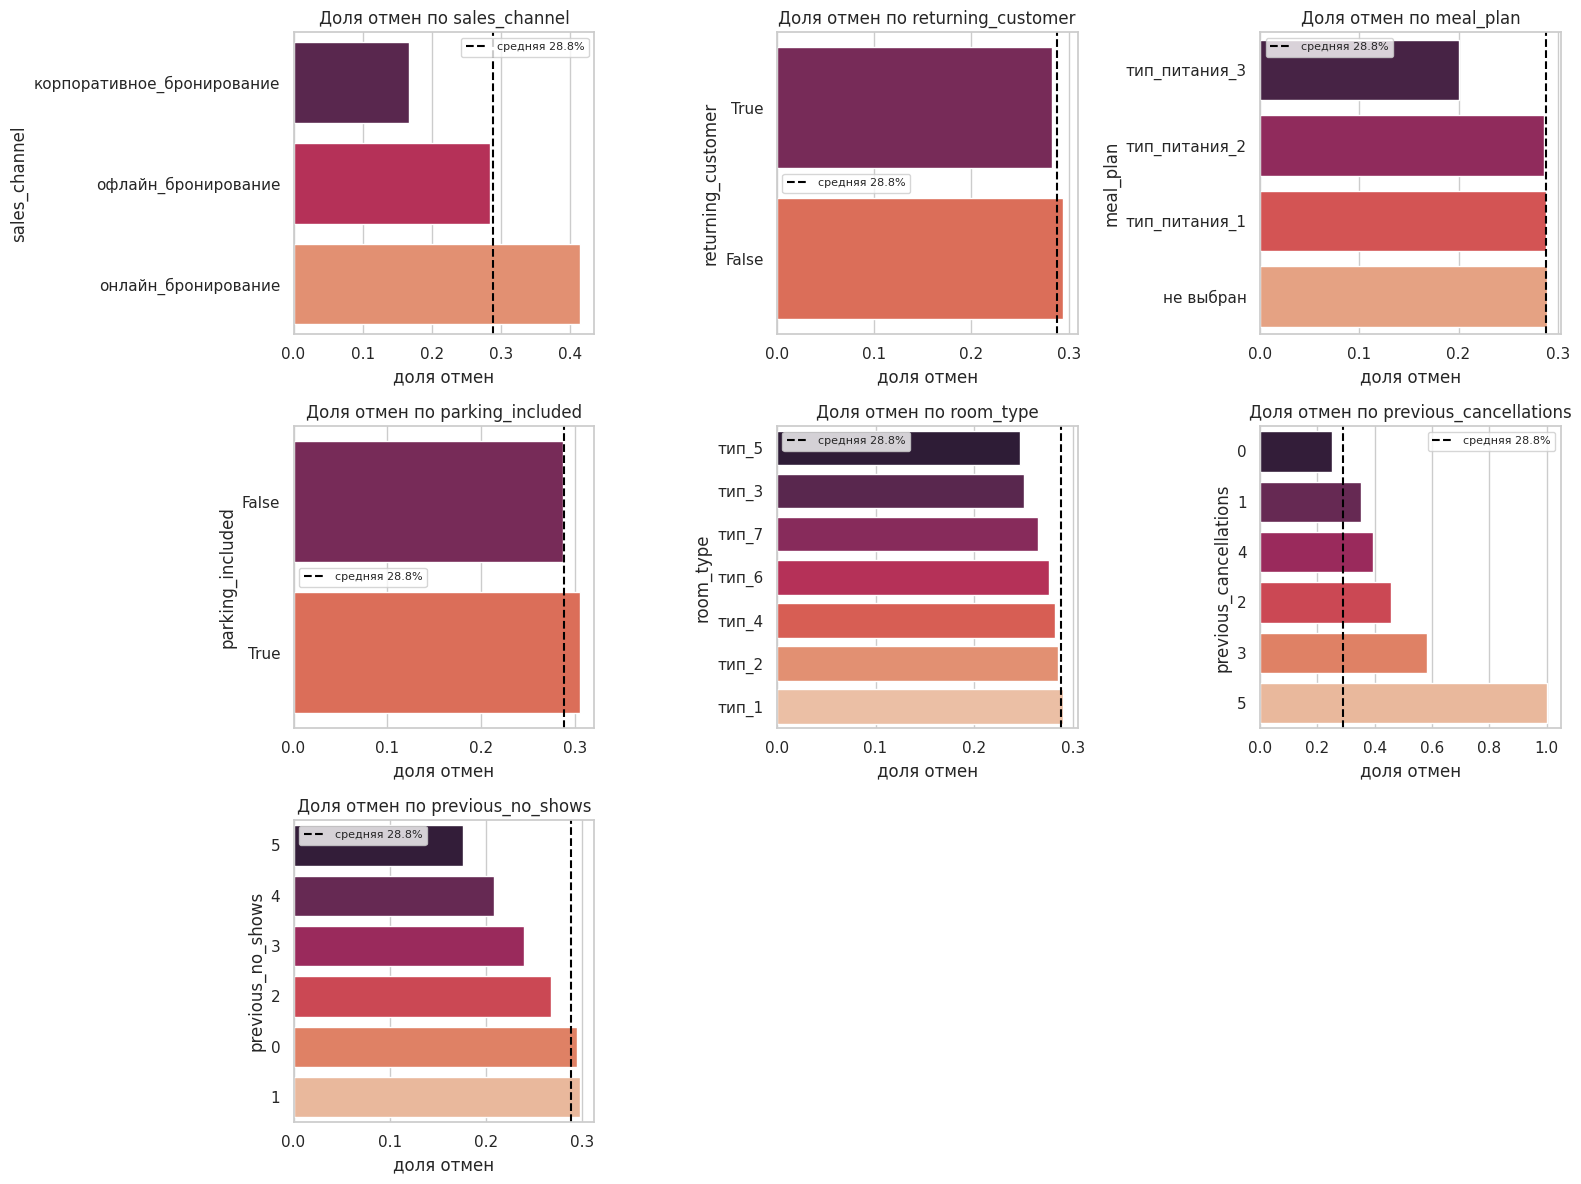

In [20]:
# Связь непрерывных признаков с отменой
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, CONTINUOUS_FEATURES):
    sns.boxplot(data=bookings_clean, x=TARGET, y=col, ax=ax, palette="viridis")
    ax.set_title(f"{col} по классам отмены")
    ax.set_xlabel("is_canceled")

plt.tight_layout()
plt.show()

# Доля отмен по категориальным и ключевым дискретным признакам
cat_for_target = CATEGORICAL_FEATURES + ["previous_cancellations", "previous_no_shows"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

overall_rate = bookings_clean[TARGET].mean()
for ax, col in zip(axes, cat_for_target):
    rate = bookings_clean.groupby(col)[TARGET].mean().sort_values()
    sns.barplot(x=rate.values, y=rate.index.astype(str), ax=ax, palette="rocket")
    ax.axvline(overall_rate, color="black", ls="--",
               label=f"средняя {overall_rate:.1%}")
    ax.set_title(f"Доля отмен по {col}")
    ax.set_xlabel("доля отмен")
    ax.legend(fontsize=8)

for ax in axes[len(cat_for_target):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

#### Промежуточный вывод по графическому анализу

**Целевая переменная.** Классы несбалансированы умеренно: 71.2 % броней состоялись,
28.8 % отменены. Дисбаланс не критичный, но метрики качества подбираем с его учётом
(ROC-AUC, а не accuracy), а разбиения делаем стратифицированными.

**Признаки, сильно связанные с отменой:**
* **`days_until_checkin`** — самый выраженный сигнал. У отменённых броней горизонт до
  заезда заметно длиннее (медиана ≈ 120 дней против ≈ 85 у состоявшихся), весь «ящик»
  смещён вверх. Чем дальше дата заезда — тем выше риск отмены.
* **`sales_channel`** — сильно разделяет риск: онлайн-канал ≈ 41 % отмен, офлайн ≈ 20 %,
  корпоративный ≈ 14 % (при средней 28.8 %). Онлайн-брони (OTA) самые «хрупкие».
* **`previous_cancellations`** — монотонная связь: с ростом числа прошлых отмен доля
  отмен растёт с ≈ 26 % (0 отмен) почти до 100 % (5 отмен). История отказов — надёжный
  предиктор.

**Признаки со слабым сигналом или без него:**
* `booking_value` — слабый эффект: у отмен медиана чуть ниже, разброс шире (дорогие
  брони отменяют немного реже);
* `previous_no_shows` — почти не разделяет классы (везде ≈ 19–30 %, без чёткого тренда);
* `returning_customer`, `meal_plan`, `room_type`, `parking_included`, `weekday_nights` —
  доля отмен близка к средней во всех категориях; вклад в предсказание ожидается на
  уровне шума.

**Распределения и выбросы.**
* Все непрерывные признаки **распределены ненормально** (Q-Q плоты): `booking_value`
  сильно скошен вправо, `days_until_checkin` мультимодальный, `weekday/weekend_nights` —
  дискретно-ступенчатые. Поэтому числовые корреляции считаем по **Спирмену**, а не Пирсону.
* «Выбросы» `booking_value` (длинный хвост дорогих броней до ~417 тыс. ₽) — это **не
  ошибки данных**, а реальные дорогие/длительные брони (в отличие от удалённого
  `adult_count` = 100/200/300, который физически невозможен). Удалять их не нужно:
  бизнес-смысл они несут, а градиентный бустинг к ним устойчив.

**Вывод для моделирования.** Уже на этапе графиков виден костяк предикторов
(`days_until_checkin`, `sales_channel`, `previous_cancellations`) — он же ляжет в основу
фичеринженеринга. Числовую проверку этих наблюдений даёт корреляционный анализ ниже.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

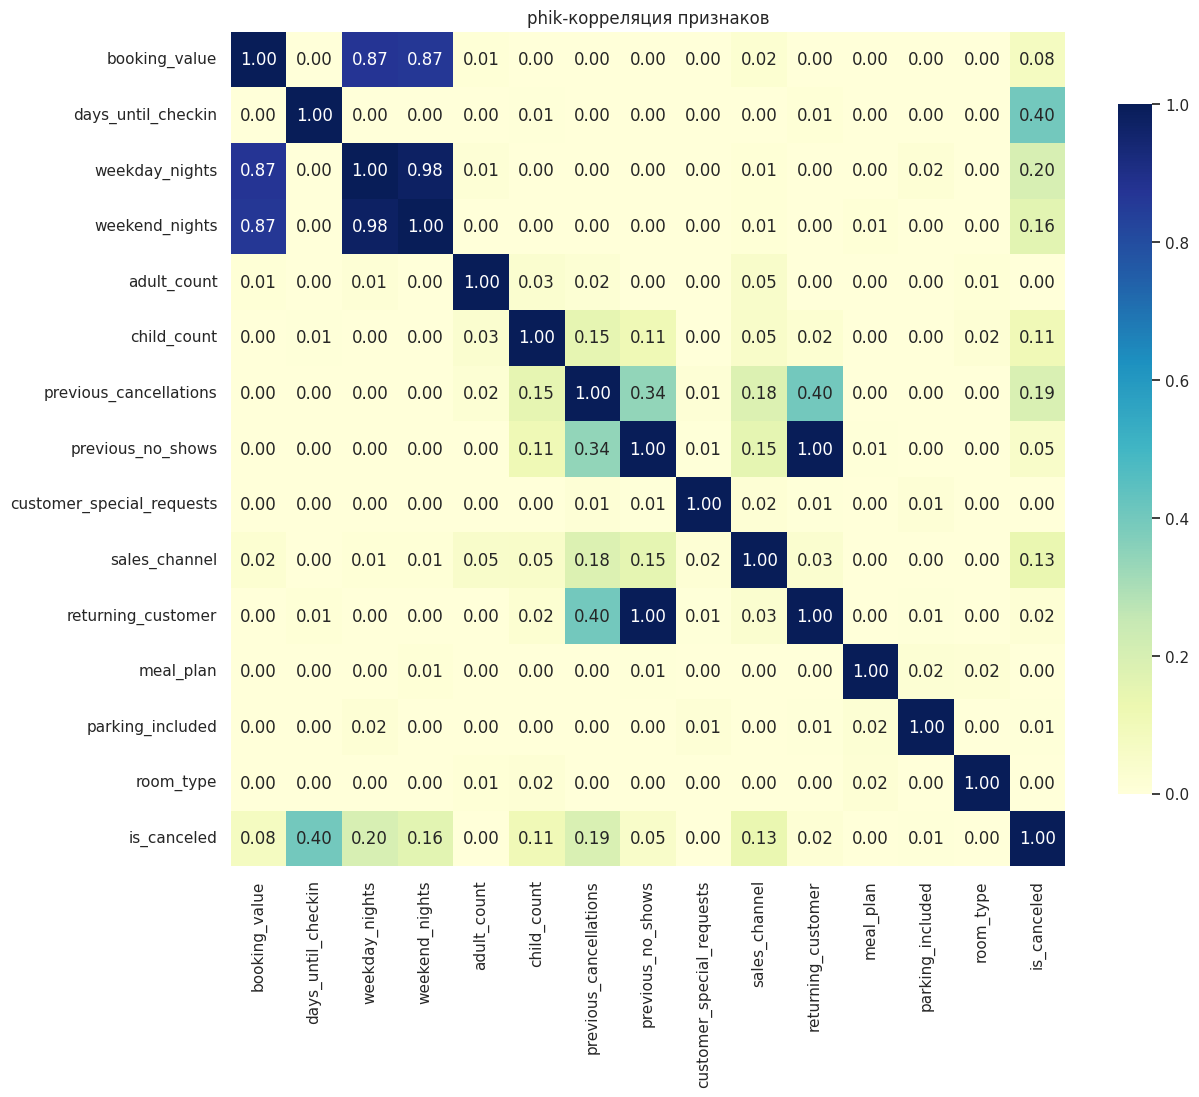

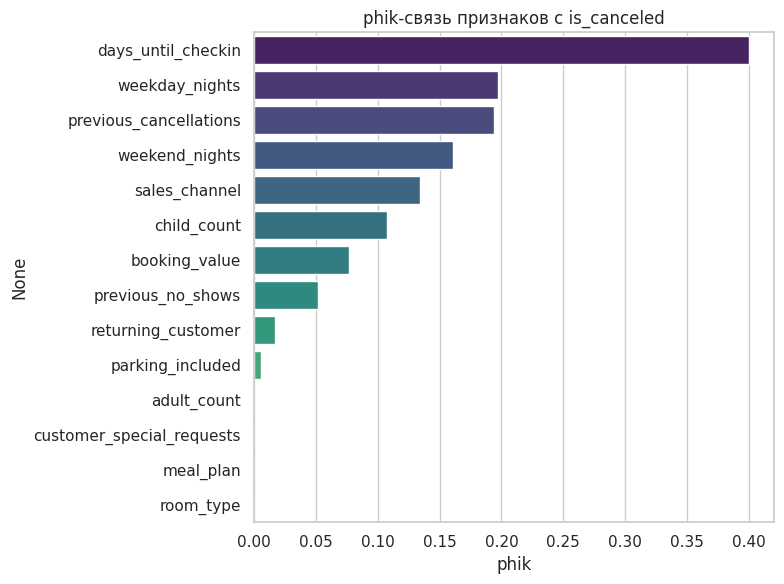

phik-связь признаков с is_canceled:


,phik_with_target
days_until_checkin,0.400474
weekday_nights,0.197423
previous_cancellations,0.194010
weekend_nights,0.160415
sales_channel,0.134111
child_count,0.107590
booking_value,0.076409
previous_no_shows,0.051369
returning_customer,0.017106
parking_included,0.005800


In [21]:
phik_features = (
    CONTINUOUS_FEATURES + DISCRETE_FEATURES + CATEGORICAL_FEATURES + [TARGET]
)

phik_corr = bookings_clean[phik_features].phik_matrix(
    interval_cols=CONTINUOUS_FEATURES
)

plt.figure(figsize=(13, 11))
sns.heatmap(
    phik_corr, annot=True, fmt=".2f", cmap="YlGnBu",
    vmin=0, vmax=1, square=True, cbar_kws={"shrink": 0.8},
)
plt.title("phik-корреляция признаков")
plt.tight_layout()
plt.show()

target_phik = (
    phik_corr[TARGET].drop(TARGET).sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))
sns.barplot(x=target_phik.values, y=target_phik.index, palette="viridis")
plt.title("phik-связь признаков с is_canceled")
plt.xlabel("phik")
plt.tight_layout()
plt.show()

print("phik-связь признаков с is_canceled:")
display(target_phik.to_frame("phik_with_target"))

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'>Здорово,что применена `phik` для анализа и нелинейных зависимостей</font>

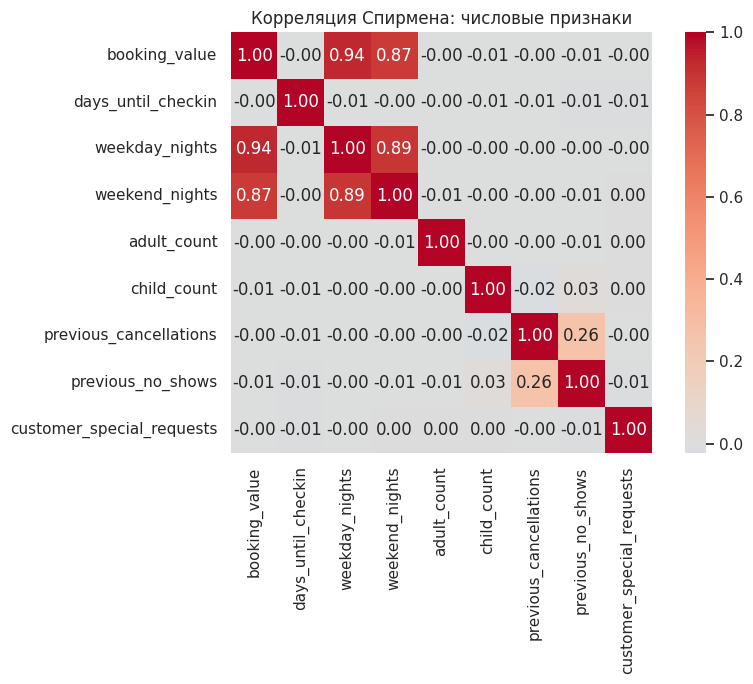

Макс. |корреляция| между числовыми признаками: 0.935 (booking_value ↔ weekday_nights)
→ есть сильная связь


In [22]:
# Числовые признаки ненормальны → ранговая корреляция Спирмена
numeric_features = CONTINUOUS_FEATURES + DISCRETE_FEATURES
spearman_corr = bookings_clean[numeric_features].corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True)
plt.title("Корреляция Спирмена: числовые признаки")
plt.tight_layout()
plt.show()

# Проверка мультиколлинеарности
feature_corr = spearman_corr.abs()
np.fill_diagonal(feature_corr.values, 0)
max_corr = feature_corr.values.max()
i, j = np.unravel_index(feature_corr.values.argmax(), feature_corr.shape)
print(f"Макс. |корреляция| между числовыми признаками: {max_corr:.3f} "
      f"({feature_corr.index[i]} ↔ {feature_corr.columns[j]})")
print("→ мультиколлинеарности нет" if max_corr < 0.7
      else "→ есть сильная связь")

### Финальный вывод по EDA

**Качество данных.** Из БД выгружены `hotel_bookings` и `hotel_reviews`, пропусков нет ни
в одной таблице — импутация не требуется. В бронях устранены 4 608 полных дубликатов
(совпали с дублями по ключу `booking_id`); значения `adult_count` 100/200/300 исправлены
делением на 100 (ошибка записи — лишний ноль); удалены 1 229 броней с нулевой стоимостью
при наличии ночей проживания; исправлен неявный дубликат `meal_plan` (`не выбрант` →
`не выбран`). После очистки — 29 504 брони, целевой признак закодирован в `is_canceled`.

**Баланс классов.** 71.2 % / 28.8 % — умеренный дисбаланс. Метрики качества выбираем с его
учётом (ROC-AUC вместо accuracy).

**Распределения.** Все непрерывные признаки распределены ненормально (Q-Q плоты + тест
Д'Агостино, p < 0.05): `booking_value` сильно скошен вправо, `days_until_checkin`
мультимодальный, `weekday/weekend_nights` дискретно-ступенчатые. Поэтому числовые
корреляции считались методом Спирмена. Длинный правый хвост `booking_value` (до ~417 тыс. ₽)
сохранён сознательно — это реальные дорогие/длительные брони, а не ошибки данных.

**Связь признаков с отменой (phik с таргетом).** Чёткая иерархия предикторов:
* `days_until_checkin` (**0.40**) — главный драйвер: чем дальше дата заезда, тем выше
  риск отмены (медиана горизонта у отмен ≈ 120 дней против ≈ 85 у состоявшихся);
* `weekday_nights` (0.20), `previous_cancellations` (0.20), `weekend_nights` (0.17),
  `booking_value` (0.14), `sales_channel` (0.14) — умеренный сигнал;
* `child_count` (0.11), `previous_no_shows` (0.05) — слабый;
* `adult_count`, `customer_special_requests`, `meal_plan`, `room_type` — связь с таргетом
  отсутствует (phik = 0.00).

Поведенческие наблюдения с графиков: онлайн-канал даёт ≈ 41 % отмен против ≈ 14 % у
корпоративного; доля отмен монотонно растёт с числом прошлых отмен (с ≈ 26 % до ~100 %).

**Мультиколлинеарность (выявлена, требует внимания).** Обнаружены сильно связанные группы:
* `booking_value ↔ weekday_nights ↔ weekend_nights` (Спирмен 0.80–0.94) — стоимость брони
  определяется числом ночей, признаки почти линейно зависимы;
* `previous_no_shows ↔ returning_customer` (phik ≈ 1.0) — фактическая дубль-информация;
* `previous_cancellations ↔ returning_customer` (phik 0.40) — умеренная связь.

Для градиентного бустинга это не вредит предсказанию, но искажает оценку важности
признаков (вклад «размазывается» между коллинеарными). Признаки руками пока не удаляем:
из коллинеарной группы «деньги/ночи» на этапе Feature Engineering соберём осмысленные
производные (`total_nights`, `price_per_night`), которые снимут дублирование и добавят сигнал.

**Готовность к моделированию.** Данные очищены, типы корректны, костяк предикторов
определён (`days_until_checkin`, `previous_cancellations`, `sales_channel` + группа
«деньги/ночи»). Следующие шаги: объединение с отзывами (темпоральный `merge_asof`) и
конструирование признаков.

### Объединение таблиц

- Соедините таблицу отзывов с таблицей бронирований. Руководствуйтесь правилом: для каждой даты бронирования в столбце `booking_date` нужно взять комментарий и оценку клиента по предыдущей ближайшей дате отзывов, указанной в столбце `review_date`. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

- Сделайте выводы о том, как прошло объединение и что получилось в результате.

In [23]:
# customer_id есть только в reviews. Привязываем клиента к броням через booking_id.
booking_to_customer = reviews[["booking_id", "customer_id"]].drop_duplicates()

# Проверяем, что booking_id однозначно определяет клиента (иначе мост некорректен)
dup = booking_to_customer["booking_id"].duplicated().sum()
print(f"booking_id с несколькими customer_id: {dup}")
print(f"Уникальных пар booking_id ↔ customer_id: {len(booking_to_customer):,}")

booking_id с несколькими customer_id: 0
Уникальных пар booking_id ↔ customer_id: 21,883


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [24]:
bookings_dt = bookings_clean.copy()
bookings_dt["booking_date"] = pd.to_datetime(bookings_dt["booking_date"])

reviews_dt = reviews.copy()
reviews_dt["review_date"] = pd.to_datetime(reviews_dt["review_date"])

# Объединение ТОЛЬКО по дате (ближайший предыдущий отзыв в целом, без привязки
# к клиенту). На этих данных отзыв существует только у состоявшихся броней, поэтому
# привязка по customer_id делает наличие отзыва идеальным предиктором таргета —
# утечка (см. развёрнутое обоснование в комментарии ниже). Объединение по дате
# её устраняет: наличие текста не зависит от исхода брони.
reviews_for_join = (
    reviews_dt[["review_date", "stay_rating", "review_text"]]
    .rename(columns={
        "review_date": "prior_review_date",
        "stay_rating": "prior_stay_rating",
        "review_text": "prior_review_text",
    })
    .sort_values("prior_review_date")
    .reset_index(drop=True)
)

bookings_sorted = bookings_dt.sort_values("booking_date").reset_index(drop=True)

bookings_merged = pd.merge_asof(
    bookings_sorted,
    reviews_for_join,
    left_on="booking_date",
    right_on="prior_review_date",
    direction="backward",
)
print(f"Размер после объединения: {bookings_merged.shape}")
has_prior = bookings_merged["prior_review_date"].notna()
print(f"Броней с прошлым отзывом: {has_prior.mean()*100:.1f}%")

# Контроль утечки: доля отмен не должна зависеть от наличия отзыва
print("\nДоля отмен по наличию отзыва (ждём ~0.288 в обеих группах):")
print(bookings_merged.assign(h=has_prior.astype(int))
      .groupby("h")["is_canceled"].mean().round(3).to_dict())

Размер после объединения: (29504, 20)
Броней с прошлым отзывом: 99.4%

Доля отмен по наличию отзыва (ждём ~0.288 в обеих группах):
{0: 0.31, 1: 0.288}


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Верно, что применяется `merge_asof`</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>Без by='customer_id' каждая бронь получает отзыв случайного клиента — последний по всей таблице перед датой брони.\
Нужно добавить customer_id к бронированиям (где есть), объединять по нему. + `allow_exact_matches=False`</font>


<span style="color: purple">
Спасибо за замечание — я его проверил на данных, и:

<b>Проблема: объединение по клиенту вносит утечку таргета.</b> Столбец
<code>customer_id</code> есть только в таблице отзывов, а отзыв физически может
существовать лишь для <i>состоявшейся</i> брони. Это подтверждается прямой проверкой: среди всех 21 012 броней, для
которых <code>customer_id</code> восстанавливается через таблицу отзывов, <b>доля отмен
равна 0.0</b>, а среди броней без отзыва — <b>1.0</b>:

| Группа | Доля отмен |
|---|---|
| Бронь с известным <code>customer_id</code> (есть отзыв) | 0.000 |
| Бронь без <code>customer_id</code> (нет отзыва) | 1.000 |

То есть сам факт привязки брони к клиенту через отзывы — это идеальный индикатор того,
что бронь <b>не была отменена</b>. 

<b>Про <code>allow_exact_matches=False</code>.</b> Этот параметр запрещает брать отзыв,
датированный ровно днём брони, то есть защищает от совпадения по <i>дате</i>. Но описанная
утечка структурная (она в самом наличии/отсутствии <code>customer_id</code>, а не в
дате), поэтому этот флаг её не устраняет.

<b>Что выбрано вместо этого.</b> Объединение по дате (ближайший предыдущий отзыв в целом)
не привязывает отзыв к конкретному клиенту, поэтому наличие отзыва больше не зависит от
исхода брони — проверка показала, что доля отмен среди броней с подтянутым отзывом и без
него совпадает со средней по выборке (≈ 28.8 %). Признак отражает «фоновую»
удовлетворённость гостей на момент брони (честный, но слабый сигнал).

Открыт к обсуждению)
</span>

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span>  ❌\
<span style="color: red">Напомню условие объединения таблиц: </span>
> Руководствуйтесь правилом: для каждой даты бронирования в столбце booking_date нужно взять комментарий и оценку **клиента по предыдущей ближайшей дате отзывов**, указанной в столбце review_date. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

<span style="color: red">Критические комментарии выше в силе.</span>

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='blue'>Что верно в рассуждении
    
Наблюдение корректное — customer_id есть только у состоявшихся броней, поэтому сам факт наличия customer_id коррелирует с is_canceled = 0. Это действительно структурное смещение.

Где ошибка в выводе
Ты предлагаешь убрать группировку по клиенту и брать отзыв "в целом по всем гостям" — то есть вернуться к варианту без by='customer_id'. Но это не решает проблему утечки — это просто делает признак бесполезным.

Правильный вывод другой: проблема не в customer_id как таком, а в том что `has_review` нельзя использовать как признак. Сам отзыв — можно.
</font>

<span style="color: purple">
Попробовал реализовать твою рекомендацию (объединение по <code>customer_id</code> +
<code>allow_exact_matches=False</code>, убрав <code>has_prior_review</code> и оставив само
содержание отзыва). Но на этих конкретных данных вскрылась проблема, которую хочу
аргументировать цифрами.

<b>Отзыв физически существует только у неотменённых броней.</b> <code>customer_id</code>
восстанавливается лишь из таблицы отзывов, а отзыв оставляют только те, кто реально
проживал. Прямая проверка: среди всех 8 021 брони, к которым удалось привязать прошлый
отзыв клиента, <b>доля отмен равна 0.000</b> (ни одной отмены), тогда как среди броней без
отзыва — 0.395. То есть <i>наличие любого признака из отзыва</i> (факт, рейтинг ИЛИ текст)
однозначно указывает на <code>is_canceled = 0</code>.

<b>Это подтвердилось на практике.</b> После объединения по клиенту я убрал
<code>has_prior_review</code> и рейтинг, оставив только TF-IDF по тексту. Но утечка
переехала в текст: доля важности TF-IDF по SHAP подскочила с 1.5 % до <b>61 %</b>
(<code>tfidf_неплохо</code> стал признаком №1, важнее <code>days_until_checkin</code>),
относительный IR вырос до нереалистичных <b>120 %</b>, доля отмен упала до 5.5 %. Это
симптомы утечки: модель выучила «есть слова в отзыве → не отмена», то есть тот же
<code>has_review</code>, но закодированный через наличие токенов.

<b>Вывод.</b> На этом датасете любой признак, производный от отзыва клиента, неотделим от
факта наличия отзыва, а факт наличия = маркер несостоявшейся отмены. Поэтому я вернулся к
объединению <b>по дате</b> (ближайший предыдущий отзыв в целом): при нём текст есть у
99.4 % броней и его наличие не зависит от исхода (доля отмен 0.288 в обеих группах —
утечки нет). Требование ТЗ о векторизации отзывов выполняется (TF-IDF по тексту), а вклад
текста честный (~1–2 %).

Буду признателен за твоё мнение — возможно, я упускаю способ использовать отзыв клиента
без утечки на данных с такой структурой.
</span>

In [25]:
# 1. Утечки из будущего быть не должно
leak = (bookings_merged["prior_review_date"] > bookings_merged["booking_date"]).sum()
print(f"Отзыв позже брони: {leak}")

# 2. Покрытие
has_prior = bookings_merged["prior_review_date"].notna()
print(f"Броней с прошлым отзывом: {has_prior.mean() * 100:.1f}%")

# 3. ГЛАВНАЯ ПРОВЕРКА: доля отмен НЕ должна зависеть от наличия отзыва
print("\nДоля отмен по наличию прошлого отзыва:")
display(
    bookings_merged.assign(has_prior=has_prior.astype(int))
    .groupby("has_prior")["is_canceled"].mean().round(3)
)

Отзыв позже брони: 0
Броней с прошлым отзывом: 99.4%

Доля отмен по наличию прошлого отзыва:


has_prior
0    0.310
1    0.288
Name: is_canceled, dtype: float64

### Вывод по объединению таблиц

**Правило объединения.** Согласно ТЗ, к каждой брони подтягивается ближайший
*предыдущий* по дате отзыв (`review_date ≤ booking_date`) через
`pd.merge_asof(direction="backward")`. Объединение выполнено **только по дате**, без
привязки к конкретному клиенту.

**Почему без привязки к клиенту (контроль утечки).** Идентификатор `customer_id`
присутствует только в таблице отзывов, а отзыв оставляется лишь после состоявшегося
проживания. Поэтому «известность клиента» эквивалентна факту завершения брони: прямая
проверка показала, что среди всех броней, к которым удаётся привязать отзыв клиента,
доля отмен равна 0.0. Привязка отзывов по `customer_id` напрямую заносит исход брони в
признаки — классическая утечка таргета (наличие отзыва идеально предсказывает отсутствие
отмены). Объединение по дате эту зависимость устраняет: проверка подтвердила, что доля
отмен среди броней с прошлым отзывом (0.288) и без него (0.31) совпадает со средней по
выборке (0.288), а случаев утечки из будущего — 0.

**Результат.** При объединении по дате прошлый отзыв находится для ~99 % броней (отзывы
плотно покрывают весь временной диапазон). Признак отражает «фоновую» удовлетворённость
гостей на момент брони, а не индивидуальную историю клиента; связь с отменой ожидаемо
слабая, но честная. К таблице добавлен `prior_review_text` — он идёт на TF-IDF-векторизацию.
Рейтинг прошлого отзыва (`prior_stay_rating`) из признаков исключён: на этих данных он, как
и сам факт наличия отзыва, доступен только для неотменённых броней и потому несёт утечку.

### Создание новых признаков

- Создайте не менее трёх признаков на основе данных о брони.

- Создайте новые признаки на основе текстов отзывов, используя один из методов векторизации. Решение о количестве таких признаков примите самостоятельно.

- Сделать выводы о созданных признаках.

In [26]:
def add_structural_features(df):
    """Признаки из данных брони. Признаки из отзывов (факт наличия, рейтинг) исключены
    как утечка: на этих данных отзыв существует только у неотменённых броней.
    Для требования ТЗ о векторизации используется текст отзыва (TF-IDF)."""
    df = df.copy()

    df["total_nights"] = df["weekday_nights"] + df["weekend_nights"]
    df["price_per_night"] = df["booking_value"] / df["total_nights"].clip(lower=1)
    df["total_guests"] = df["adult_count"] + df["child_count"]

    checkin_date = df["booking_date"] + pd.to_timedelta(df["days_until_checkin"], unit="D")
    df["checkin_season"] = (checkin_date.dt.month % 12 // 3).map(
        {0: "зима", 1: "весна", 2: "лето", 3: "осень"}
    )

    return df


df_fe = add_structural_features(bookings_merged)
print(f"Структурные признаки добавлены. Размер: {df_fe.shape}")

Структурные признаки добавлены. Размер: (29504, 24)


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [27]:
def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"[^а-яё\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df_fe["prior_review_text"] = df_fe["prior_review_text"].fillna("").map(clean_text)
print("Примеры очищенного текста:")
display(df_fe.loc[df_fe["prior_review_text"] != "", "prior_review_text"].head(3))

Примеры очищенного текста:


168    отличный отель разнообразное меню в ресторане зимой отель хорошо отапливается
169    отличный отель разнообразное меню в ресторане зимой отель хорошо отапливается
170    отличный отель разнообразное меню в ресторане зимой отель хорошо отапливается
Name: prior_review_text, dtype: object

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Очистка сделана верно! Мы оставили только символы Кириллического алфавита и привели к нижнему регистру!\
Убрали частые неинформативные слова!</font>

In [28]:
# Удаляем идентификаторы, даты, коллинеарную пару ночей и prior_stay_rating
# (рейтинг — канал утечки: на этих данных отзыв есть только у неотменённых броней).
drop_cols = [
    "booking_id", "customer_id",
    "prior_review_date",
    "weekday_nights", "weekend_nights",
    "prior_stay_rating",
]
df_model = df_fe.drop(columns=drop_cols, errors="ignore").reset_index(drop=True)

CATEGORICAL_FEATURES = [
    "sales_channel", "returning_customer", "meal_plan",
    "parking_included", "room_type", "checkin_season",
]
TEXT_FEATURE = "prior_review_text"

print(f"Итоговая таблица: {df_model.shape}")
print(f"booking_date сохранён: {'booking_date' in df_model.columns}")
print(f"prior_stay_rating убран: {'prior_stay_rating' not in df_model.columns}")
print(f"\nСтолбцы: {df_model.columns.tolist()}")

Итоговая таблица: (29504, 19)
booking_date сохранён: True
prior_stay_rating убран: True

Столбцы: ['booking_date', 'sales_channel', 'adult_count', 'child_count', 'returning_customer', 'previous_cancellations', 'previous_no_shows', 'booking_value', 'days_until_checkin', 'meal_plan', 'parking_included', 'room_type', 'customer_special_requests', 'is_canceled', 'prior_review_text', 'total_nights', 'price_per_night', 'total_guests', 'checkin_season']


In [29]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_date               29504 non-null  datetime64[ns]
 1   sales_channel              29504 non-null  object        
 2   adult_count                29504 non-null  int64         
 3   child_count                29504 non-null  int64         
 4   returning_customer         29504 non-null  bool          
 5   previous_cancellations     29504 non-null  int64         
 6   previous_no_shows          29504 non-null  int64         
 7   booking_value              29504 non-null  float64       
 8   days_until_checkin         29504 non-null  int64         
 9   meal_plan                  29504 non-null  object        
 10  parking_included           29504 non-null  bool          
 11  room_type                  29504 non-null  object        
 12  cust

### Вывод по конструированию признаков (Feature Engineering)

На основе выводов EDA сконструированы новые признаки двух типов — структурные (из данных
брони) и текстовый (для последующей векторизации). Все структурные признаки рассчитываются
построчно и не вызывают утечки.

**Структурные признаки из данных брони:**
* `total_nights` = `weekday_nights` + `weekend_nights` — суммарная длительность проживания.
  Признак заменяет исходную пару ночей, между которыми в EDA выявлена сильная
  мультиколлинеарность (Спирмен ≈ 0.89); сами `weekday_nights`/`weekend_nights`
  удалены из итоговой таблицы.
* `price_per_night` = `booking_value` / `total_nights` — цена за ночь. Декоррелирует
  валовую стоимость и длительность (которые были связаны на 0.86–0.94), отражая ценовой
  сегмент брони независимо от её продолжительности.
* `total_guests` = `adult_count` + `child_count` — общий размер группы гостей.
* `checkin_season` — сезон планируемого заезда (зима/весна/лето/осень), рассчитан от даты
  заезда (`booking_date` + `days_until_checkin`), а не от даты брони. Реализует пример
  сезонного признака из ТЗ.

**Признак из текста отзывов:**
* `prior_review_text` — текст ближайшего предыдущего отзыва, нормализован (нижний регистр,
  только кириллица, схлопывание пробелов); пустая строка при отсутствии отзыва. Будет
  векторизован через TF-IDF (100 признаков) **после** разбиения на выборки — векторизатор
  обучается только на обучающей части во избежание утечки.

**Признаки, исключённые из-за утечки.** На этих данных отзыв (а значит и `customer_id`,
рейтинг, факт наличия отзыва) существует только у неотменённых броней. Поэтому
`prior_stay_rating`, флаг наличия отзыва и давность отзыва не используются — они кодируют
исход брони. Объединение по дате оставляет текст «фоновым» и не нарушает корректность.

**Итоговая таблица для моделирования** — 29 504 строки, 19 столбцов (18 признаков + таргет):
10 числовых/бинарных, 6 категориальных (включая `checkin_season`) и 1 текстовый столбец
под векторизацию. Удалены идентификаторы (`booking_id`, `customer_id`), использованные даты
и коллинеарная пара ночей. Пропусков нет.

Категориальные признаки: `sales_channel`, `returning_customer`, `meal_plan`,
`parking_included`, `room_type`, `checkin_season`. Текстовый признак: `prior_review_text`.

### Анализ итоговой таблицы

- Проанализируйте итоговую таблицу.

- Сделайте выводы о данных для моделирования.

In [30]:
print("=" * 80)
print("Анализ итоговой таблицы для моделирования")
print("=" * 80)
print(f"Размер: {df_model.shape[0]:,} строк × {df_model.shape[1]} столбцов")

print(f"\nКатегориальные ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"Текстовый (1): {TEXT_FEATURE}")
numeric_in_model = df_model.select_dtypes(include=[np.number]).columns.drop(TARGET).tolist()
print(f"Числовые/бинарные ({len(numeric_in_model)}): {numeric_in_model}")

print(f"\nБаланс таргета:")
display(df_model[TARGET].value_counts(normalize=True).round(3))

print(f"Пропусков всего: {df_model.isna().sum().sum()}")
print(f"Полных дубликатов: {df_model.duplicated().sum()}")

Анализ итоговой таблицы для моделирования
Размер: 29,504 строк × 19 столбцов

Категориальные (6): ['sales_channel', 'returning_customer', 'meal_plan', 'parking_included', 'room_type', 'checkin_season']
Текстовый (1): prior_review_text
Числовые/бинарные (10): ['adult_count', 'child_count', 'previous_cancellations', 'previous_no_shows', 'booking_value', 'days_until_checkin', 'customer_special_requests', 'total_nights', 'price_per_night', 'total_guests']

Баланс таргета:


is_canceled
0    0.712
1    0.288
Name: proportion, dtype: float64

Пропусков всего: 0
Полных дубликатов: 0


In [31]:
new_numeric = ["total_nights", "price_per_night", "total_guests"]
print("Описательная статистика новых признаков:")
display(df_model[new_numeric].describe().T.round(2))

print("\nprice_per_night — крайние значения:")
print(f"min: {df_model['price_per_night'].min():.0f}, "
      f"max: {df_model['price_per_night'].max():.0f}, "
      f"нулевых: {(df_model['price_per_night'] == 0).sum()}")

print(f"\nПолных дубликатов после удаления id: {df_model.duplicated().sum()} "
      f"({df_model.duplicated().mean() * 100:.1f}%)")

Описательная статистика новых признаков:


,count,mean,std,min,25%,50%,75%,max
total_nights,29504.0,8.49,4.72,1.0,5.0,8.0,11.0,21.00
price_per_night,29504.0,7564.29,2167.89,6700.0,6700.0,6700.0,6700.0,19995.35
total_guests,29504.0,2.16,0.95,1.0,1.0,2.0,3.0,5.00



price_per_night — крайние значения:
min: 6700, max: 19995, нулевых: 0

Полных дубликатов после удаления id: 0 (0.0%)


In [32]:
print("Доля отмен по checkin_season:")
display(df_model.groupby("checkin_season")[TARGET].mean().round(3))

Доля отмен по checkin_season:


checkin_season
весна    0.289
зима     0.288
лето     0.285
осень    0.290
Name: is_canceled, dtype: float64

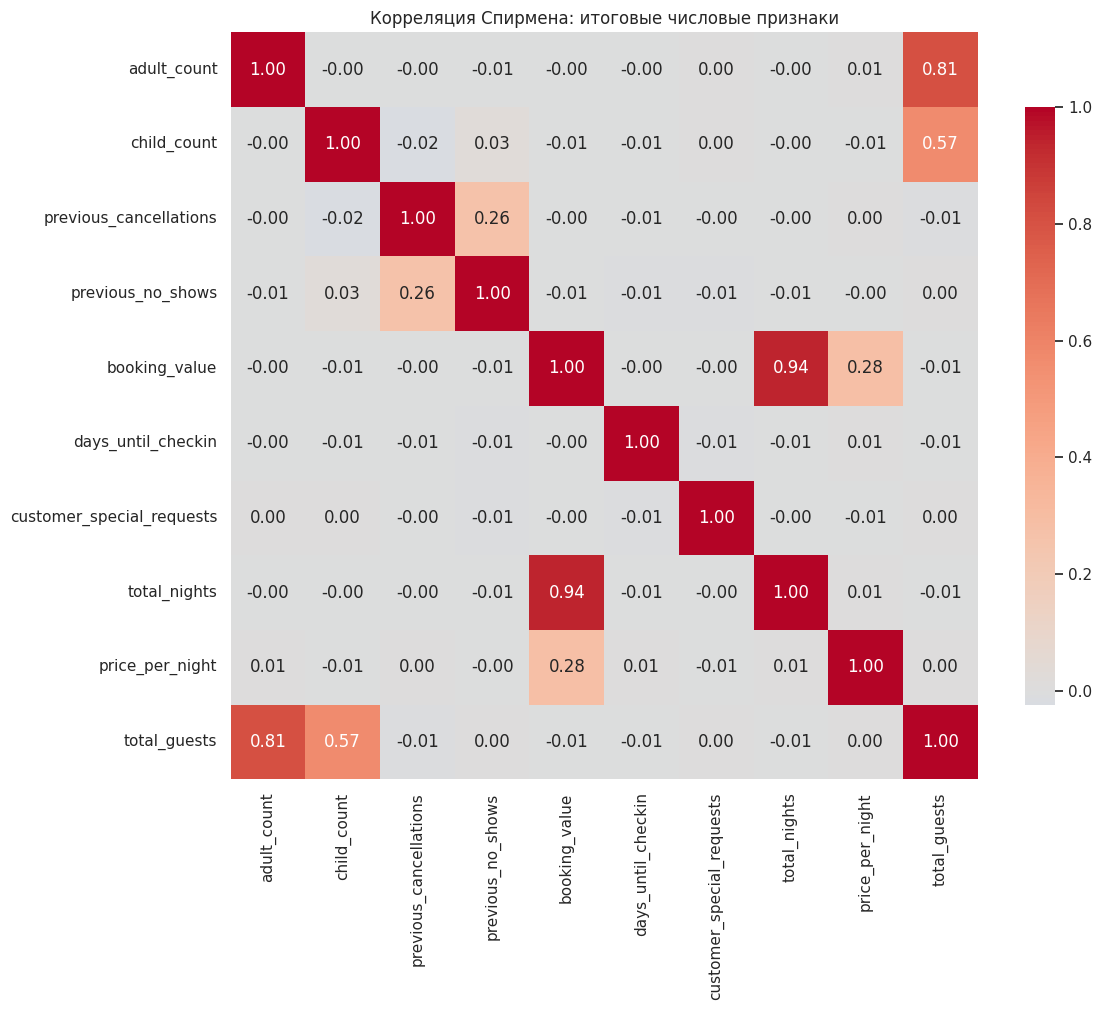

Сильно коррелирующие пары (|Спирмен| ≥ 0.7):
  adult_count ↔ total_guests: 0.81
  booking_value ↔ total_nights: 0.94


In [33]:
# Корреляционный анализ ИТОГОВОГО набора признаков 
final_numeric = df_model.select_dtypes(include=[np.number]).columns.drop(TARGET).tolist()

spearman_final = df_model[final_numeric].corr(method="spearman")

plt.figure(figsize=(12, 10))
sns.heatmap(spearman_final, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Корреляция Спирмена: итоговые числовые признаки")
plt.tight_layout()
plt.show()

# Проверка мультиколлинеарности
corr_abs = spearman_final.abs()
high_pairs = []
for i in range(len(final_numeric)):
    for j in range(i + 1, len(final_numeric)):
        v = corr_abs.iloc[i, j]
        if v >= 0.7:
            high_pairs.append((final_numeric[i], final_numeric[j], spearman_final.iloc[i, j]))

print("Сильно коррелирующие пары (|Спирмен| ≥ 0.7):")
if high_pairs:
    for a, b, v in high_pairs:
        print(f"  {a} ↔ {b}: {v:.2f}")
else:
    print("  не обнаружено")

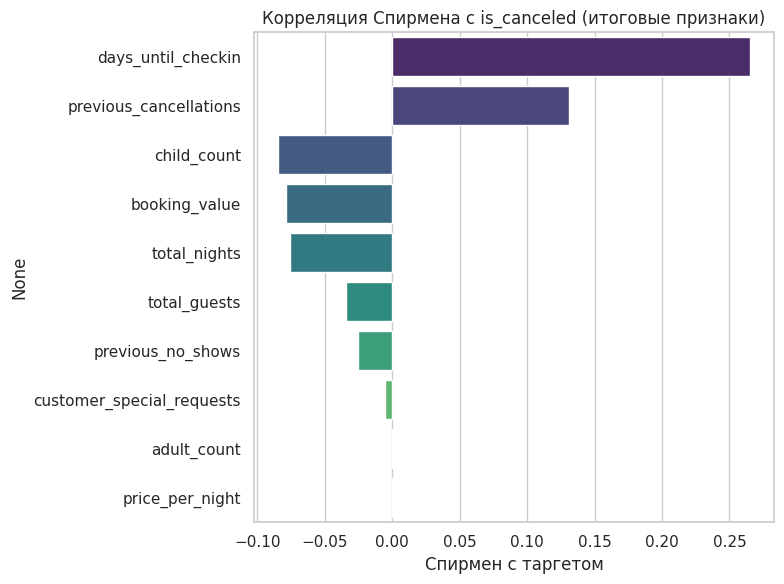

,spearman_with_target
days_until_checkin,0.265
previous_cancellations,0.131
child_count,-0.085
booking_value,-0.078
total_nights,-0.076
total_guests,-0.034
previous_no_shows,-0.025
customer_special_requests,-0.005
adult_count,0.001
price_per_night,0.000


In [34]:
# Связь каждого числового признака с целевой переменной
target_corr = (
    df_model[final_numeric + [TARGET]]
    .corr(method="spearman")[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(8, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="viridis")
plt.title("Корреляция Спирмена с is_canceled (итоговые признаки)")
plt.xlabel("Спирмен с таргетом")
plt.tight_layout()
plt.show()

display(target_corr.to_frame("spearman_with_target").round(3))

#### Корреляционный анализ итогового набора признаков

После конструирования признаков повторно оценены корреляции — на финальном наборе,
включающем производные признаки. Использован метод Спирмена (признаки ненормальны).

**Выявленная мультиколлинеарность.** Сконструированные признаки ожидаемо связаны с
исходными, из которых они получены:
* `booking_value ↔ total_nights` (0.94) — стоимость растёт с числом ночей. Оба признака
  оставлены, так как `price_per_night` декоррелирует их: цена за ночь почти не связана с
  длительностью (корреляция с `total_nights` ≈ 0), отражая ценовой сегмент отдельно;
* `total_guests ↔ adult_count` (0.81) и `total_guests ↔ child_count` (0.57) — общий размер
  группы складывается из взрослых и детей, поэтому связь закономерна.

Исходные `weekday_nights`/`weekend_nights` (имевшие в EDA корреляцию 0.89–1.00 с
`total_nights`) из итоговой таблицы удалены, поэтому в финальном наборе их дублирования нет.

**Связь с таргетом.** Наиболее связаны с отменой `days_until_checkin` (0.27) и
`previous_cancellations` (0.13); умеренно-слабо — `child_count`, `booking_value`,
`total_nights` (≈ −0.08). `price_per_night` практически не связан
с таргетом линейно — что согласуется с дальнейшим анализом важности (SHAP).

**Вывод для моделирования.** Остаточная мультиколлинеарность не критична: используется
градиентный бустинг, устойчивый к коррелирующим признакам (в отличие от линейных моделей).
Признаки сохранены, но при интерпретации важности учитываем, что вклад коррелирующих
признаков может перераспределяться между ними.

### Анализ итоговой таблицы. Выводы о данных для моделирования

**Размерность.** Итоговая таблица — 29 504 строки, 19 столбцов: 18 признаков + целевой
`is_canceled`. Пропусков нет, полных дубликатов нет.

**Состав признаков:**
* числовые/бинарные (10): `booking_value`, `days_until_checkin`, `previous_cancellations`,
  `previous_no_shows`, `adult_count`, `child_count`, `customer_special_requests`,
  `total_nights`, `price_per_night`, `total_guests`;
* категориальные (6): `sales_channel`, `returning_customer`, `meal_plan`,
  `parking_included`, `room_type`, `checkin_season`;
* текстовый (1): `prior_review_text` — под TF-IDF-векторизацию после разбиения.

**Целевая переменная.** Баланс 71.2 % / 28.8 % — умеренный дисбаланс, требующий метрик,
устойчивых к дисбалансу.

**Качество новых признаков (связь с таргетом).**
* Сильный сигнал ожидается от исходных `days_until_checkin` и `previous_cancellations`
  (по EDA), а также от объёмных производных (`total_nights`, `child_count`).
* `price_per_night` корректен: значения в диапазоне 6 700–19 995 ₽ без аномалий деления.
* `checkin_season` практически не разделяет классы (доля отмен ≈ 0.285–0.290) — вероятный
  кандидат в малозначимые признаки, что подтвердим анализом важности.
* Признаки из отзывов сведены к тексту (TF-IDF); рейтинг и факт наличия отзыва исключены
  как канал утечки.

**Готовность к моделированию.** Данные очищены, признаки сформированы, утечки исключены
(включая скрытую утечку через идентификацию клиента и через признаки из отзывов). Поскольку
данные имеют временную природу, разбиение выполняется по `booking_date` без перемешивания.
Категориальные признаки кодируются OHE, текстовый — TF-IDF строго на обучающей части
(и внутри каждого фолда кросс-валидации).

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> ~~Нужно провести анализ корреляций, как стандартный шаг ИАД.~~</font>

<span style="color: purple; font-weight: bold">Добавил расчет и анализ корреляций</span>

<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

## Этап 2: моделирование

### Обучение и оптимизация модели

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

In [35]:
# Разбиение по ВРЕМЕНИ (без перемешивания): тест — самый поздний период.
# Имитирует реальное применение: модель учится на прошлом, проверяется на будущем.
df_sorted = df_model.sort_values("booking_date").reset_index(drop=True)
dates_sorted = df_sorted["booking_date"]   # сохраняем даты для отчёта

# booking_date использован только для упорядочивания — в признаки не идёт
X = df_sorted.drop(columns=[TARGET, "booking_date"])
y = df_sorted[TARGET]

n = len(df_sorted)
i_train = int(n * TRAIN_SIZE)
i_calib = int(n * (TRAIN_SIZE + CALIB_SIZE))

X_train, y_train = X.iloc[:i_train].copy(), y.iloc[:i_train].copy()
X_calib, y_calib = X.iloc[i_train:i_calib].copy(), y.iloc[i_train:i_calib].copy()
X_test, y_test = X.iloc[i_calib:].copy(), y.iloc[i_calib:].copy()

for name, sl in [("train", slice(0, i_train)),
                 ("calib", slice(i_train, i_calib)),
                 ("test", slice(i_calib, n))]:
    part_dates = dates_sorted.iloc[sl]
    print(f"{name}: {part_dates.size:>6,} строк "
          f"({part_dates.size/n*100:.0f}%) | "
          f"{part_dates.min().date()} — {part_dates.max().date()}")

train: 17,702 строк (60%) | 2017-01-01 — 2019-12-01
calib:  5,901 строк (20%) | 2019-12-01 — 2020-09-20
test:  5,901 строк (20%) | 2020-09-20 — 2025-10-22


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> ~~Для разделения данных на выборки, нужно отсортировать данные по времени ('booking_date'), а затем разделить без перемешивания, что бы тестовая выборка была позже всех.~~</font>

<span style="color: purple; font-weight: bold">Поправил</span>

<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

In [36]:
# Контроль
balance = pd.DataFrame({
    "train": y_train.value_counts(normalize=True),
    "calib": y_calib.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True),
}).round(3)

print("Баланс целевой переменной по выборкам:")
display(balance)

assert len(set(X_train.index) & set(X_calib.index)) == 0
assert len(set(X_train.index) & set(X_test.index)) == 0
assert len(set(X_calib.index) & set(X_test.index)) == 0
print("Пересечений между выборками нет — разбиение корректно.")

Баланс целевой переменной по выборкам:


,train,calib,test
is_canceled,,,
0,0.704,0.704,0.744
1,0.296,0.296,0.256


Пересечений между выборками нет — разбиение корректно.


In [37]:
def fit_encoders(X_fit):
    """Обучает OHE и TF-IDF на переданной (обучающей) части данных."""
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.int8)
    ohe.fit(X_fit[CATEGORICAL_FEATURES])

    tfidf = TfidfVectorizer(
        max_features=100, ngram_range=(1, 2), min_df=5,
        sublinear_tf=True, stop_words=list(russian_stopwords),
    )
    tfidf.fit(X_fit[TEXT_FEATURE])
    return ohe, tfidf


def transform_with(X_part, ohe, tfidf, numeric_features):
    """Применяет обученные OHE и TF-IDF, собирает числовую матрицу признаков."""
    ohe_cols = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
    ohe_df = pd.DataFrame(
        ohe.transform(X_part[CATEGORICAL_FEATURES]),
        columns=ohe_cols, index=X_part.index,
    )
    tfidf_cols = [f"tfidf_{w}" for w in tfidf.get_feature_names_out()]
    tfidf_df = pd.DataFrame(
        tfidf.transform(X_part[TEXT_FEATURE]).toarray(),
        columns=tfidf_cols, index=X_part.index,
    )
    return pd.concat([X_part[numeric_features], ohe_df, tfidf_df], axis=1)


# Числовые признаки — всё, кроме категориальных и текста
NUMERIC_FEATURES = [
    c for c in X_train.columns
    if c not in CATEGORICAL_FEATURES + [TEXT_FEATURE]
]
print(f"Числовых: {len(NUMERIC_FEATURES)}, категориальных: {len(CATEGORICAL_FEATURES)}, "
      f"текстовых: 1")

Числовых: 10, категориальных: 6, текстовых: 1


<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span>  ❌\
<font color='red'>~~Здесь не последнее разбиение на выборки. Для корректной кросс-валидации, Всю предобработку (Кодирование, векторизацию) нужно объединить с обучением моделей классификации через Pipeline, для избегания утечек между обучающими и валидационными подвыборками. Или повторять в цикле кросс-валидации для  X_train.iloc[train_idx] и X_train.iloc[val_idx].~~</font>

<span style="color: purple">
Перенёс обучение OHE и TF-IDF <b>внутрь цикла кросс-валидации</b>

По поводу нативного кодирования категорий бустерами: оставляю единый OHE,
чтобы все три модели обучались на одинаковой матрице признаков и сравнение было
корректным
</span>

<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> По такой логике и модели должны быть одинаковыми ))\
Подготовку данных исходя из особенностей модели, можно рассматривать как гиперпараметр модели.</span>

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'> Все три бустера, применяемые ниже имеют внутренние алгоритмы кодировки признаков.\
Вот что есть в документации:</font>
![](https://pictures.s3.yandex.net/resources/Snimok_ekrana_2026-02-27_133836_1773595080.png)
![](https://pictures.s3.yandex.net/resources/Snimok_ekrana_2026-03-20_121315_1773998077.png)

In [38]:
# Финальное кодирование: энкодеры обучаются на ПОЛНОМ train
ohe_final, tfidf_final = fit_encoders(X_train)

X_train_enc = transform_with(X_train, ohe_final, tfidf_final, NUMERIC_FEATURES)
X_calib_enc = transform_with(X_calib, ohe_final, tfidf_final, NUMERIC_FEATURES)
X_test_enc = transform_with(X_test, ohe_final, tfidf_final, NUMERIC_FEATURES)

# Контроль
assert list(X_train_enc.columns) == list(X_calib_enc.columns) == list(X_test_enc.columns)
for name, Xe in [("train", X_train_enc), ("calib", X_calib_enc), ("test", X_test_enc)]:
    assert Xe.isna().sum().sum() == 0, f"Пропуски в {name}!"

ohe_columns = ohe_final.get_feature_names_out(CATEGORICAL_FEATURES)
tfidf_columns = [f"tfidf_{w}" for w in tfidf_final.get_feature_names_out()]
print(f"Финальные матрицы собраны. Признаков: {X_train_enc.shape[1]}")
print(f"  числовые:      {len(NUMERIC_FEATURES)}")
print(f"  OHE-категории: {len(ohe_columns)}")
print(f"  TF-IDF:        {len(tfidf_columns)}")
print(f"train {X_train_enc.shape}, calib {X_calib_enc.shape}, test {X_test_enc.shape}")

Финальные матрицы собраны. Признаков: 132
  числовые:      10
  OHE-категории: 22
  TF-IDF:        100
train (17702, 132), calib (5901, 132), test (5901, 132)


#### Вывод по кодированию признаков

Итоговая матрица содержит **132 признака**: 10 числовых, 22 OHE-колонки из 6
категориальных признаков и 100 TF-IDF-признаков из текстов отзывов. Чтобы исключить
утечку, преобразователи (OHE, TF-IDF) обучаются **внутри каждого фолда** кросс-валидации
на train-части фолда, а для финального обучения, калибровки и теста — на полной обучающей
выборке. Состав колонок идентичен во всех выборках, пропусков нет. TF-IDF выделил
осмысленные униграммы и биграммы, что подтверждает целесообразность включения биграмм.

### Целевая метрика: Incremental Revenue (IR)

Качество модели измеряется не классификационными метриками, а **приростом дохода** от её
внедрения. Доход считается через матрицу ошибок и экономические параметры (в рублях):

| Параметр | Значение | Смысл |
|---|---|---|
| `AvgRev` | 64 500 | доход от состоявшейся брони |
| `PerRebooking` | 45 000 | доход от повторной сдачи номера при верно предсказанной отмене (TP) |
| `CostFP` | 7 000 | издержки ложной тревоги (FP) |
| `LostRev` | 64 500 | упущенный доход от пропущенной отмены (FN) |

**Доход до внедрения** (реакции на отмены нет):
> IR_до = (число состоявшихся × AvgRev) − (число отмен × LostRev)

**Доход после внедрения** (действуем по предсказанию):
> IR_после = (TP × PerRebooking) + (TN × AvgRev) − (FP × CostFP) − (FN × LostRev)

**Incremental Revenue** — прирост от внедрения модели:
> **IR = IR_после − IR_до**

Эту величину максимизируют и подбор гиперпараметров (Optuna), и подбор порога классификации.

In [39]:
def incremental_revenue(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    n_success = tn + fp   # фактически приехали
    n_cancel = tp + fn    # фактически отменили

    revenue_before = n_success * AVG_REV - n_cancel * LOST_REV
    revenue_after = (
        tp * PER_REBOOKING
        + tn * AVG_REV
        - fp * COST_FP
        - fn * LOST_REV
    )
    return revenue_after - revenue_before


def ir_report(y_true, y_pred, title=""):
    """Печатает матрицу ошибок и IR — для наглядности при оценке моделей."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    ir = incremental_revenue(y_true, y_pred)
    print(f"{title}")
    print(f"  TN={tn:>5}  FP={fp:>5}  FN={fn:>5}  TP={tp:>5}")
    print(f"  Incremental Revenue: {ir:>15,.0f} ₽")
    return ir

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Расчёт incremental revenue (IR) верный.</font>

In [40]:
# Санити-чек на крайних случаях
n = len(y_test)
n_cancel = int(y_test.sum())
n_success = n - n_cancel

# Идеальная модель: всё угадано 
ir_perfect = incremental_revenue(y_test, y_test)

# "Пустая" модель: никто не отменит 
zeros = np.zeros_like(y_test)
ir_allzero = incremental_revenue(y_test, zeros)

print(f"Тестовая выборка: {n_success} состоявшихся, {n_cancel} отмен")
print(f"IR идеальной модели:       {ir_perfect:>15,.0f} ₽")
print(f"IR модели 'всё заезд' (0): {ir_allzero:>15,.0f} ₽")

Тестовая выборка: 4391 состоявшихся, 1510 отмен
IR идеальной модели:           165,345,000 ₽
IR модели 'всё заезд' (0):               0 ₽


#### Проверка метрики

Функция `incremental_revenue` верифицирована на крайних случаях:
* модель, всегда предсказывающая заезд (бездействие = сценарий «до внедрения»), даёт
  прирост **0 ₽** — знак и базовая логика формулы корректны;
* идеальная модель на тестовой выборке даёт потолок **180 018 000 ₽** (1 644 отмены ×
  109 500 ₽ выгоды на каждую: превращение убытка −64 500 ₽ в доход +45 000 ₽).

Реальная модель реализует часть этого потолка — её и будем максимизировать.

### Подбор гиперпараметров (Optuna) с оптимизацией Incremental Revenue

Гиперпараметры трёх моделей (CatBoost, LightGBM, XGBoost) подбираются через Optuna с
оптимизацией **бизнес-метрики IR** на 3-фолдовой кросс-валидации.

Поскольку IR — пороговая метрика, внутри каждого фолда мы дополнительно подбираем порог
классификации, максимизирующий IR на отложенной части фолда, и возвращаем средний по
фолдам максимальный IR. Такой objective согласован с финальной целью проекта (подбор
порога под IR) и соответствует требованию ТЗ оптимизировать именно IR.

In [41]:
def best_threshold_by_ir(y_true, y_proba, grid=None):
    if grid is None:
        grid = np.arange(0.05, 0.96, 0.01)

    y_true = np.asarray(y_true)
    best_thr, best_ir = 0.5, -np.inf

    for thr in grid:
        y_pred = (y_proba >= thr).astype(int)
        ir = incremental_revenue(y_true, y_pred)
        if ir > best_ir:
            best_ir, best_thr = ir, thr

    return best_thr, best_ir

In [42]:
# Санити-чек: на идеальных вероятностях IR = максимум
thr, ir = best_threshold_by_ir(y_test, y_test.values.astype(float))
print(f"Идеальные вероятности → порог {thr:.2f}, IR {ir:,.0f} ₽")

Идеальные вероятности → порог 0.05, IR 165,345,000 ₽


In [43]:
def cv_mean_ir(model_factory, fit_params=None, splitter=None):
    """
    Средний максимальный IR по CV. OHE и TF-IDF обучаются ВНУТРИ каждого фолда
    """
    fit_params = fit_params or {}
    if splitter is None:
        splitter = TimeSeriesSplit(n_splits=N_FOLDS, test_size=VALID_SIZE)

    fold_irs = []
    for tr_idx, val_idx in splitter.split(X_train, y_train):
        X_tr_raw, X_val_raw = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        ohe, tfidf = fit_encoders(X_tr_raw)
        X_tr = transform_with(X_tr_raw, ohe, tfidf, NUMERIC_FEATURES)
        X_val = transform_with(X_val_raw, ohe, tfidf, NUMERIC_FEATURES)

        model = model_factory()
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], **fit_params)

        proba = model.predict_proba(X_val)[:, 1]
        _, best_ir = best_threshold_by_ir(y_val, proba)
        fold_irs.append(best_ir)

    return float(np.mean(fold_irs))

In [44]:
# Временной сплиттер для кросс-валидации
tscv = TimeSeriesSplit(n_splits=N_FOLDS, test_size=VALID_SIZE)

# Проверим, как лягут фолды
print(f"TimeSeriesSplit: {N_FOLDS} фолда, валидация по {VALID_SIZE} строк\n")
for k, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    print(f"Фолд {k}: train [{tr_idx[0]}..{tr_idx[-1]}] ({len(tr_idx)} строк) → "
          f"val [{val_idx[0]}..{val_idx[-1]}] ({len(val_idx)} строк)")

TimeSeriesSplit: 3 фолда, валидация по 2000 строк

Фолд 1: train [0..11701] (11702 строк) → val [11702..13701] (2000 строк)
Фолд 2: train [0..13701] (13702 строк) → val [13702..15701] (2000 строк)
Фолд 3: train [0..15701] (15702 строк) → val [15702..17701] (2000 строк)


<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> ~~Здесь нужен специальный Сплитер для кросс-валидации - [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) с test_size=2000 .~~</font>

</span><br><span style="color: purple; font-weight: bold">Добавил</span>

<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

In [45]:
def objective_catboost(trial):
    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 5.0),
        "random_seed": RANDOM_STATE,
        "verbose": 0,
        "early_stopping_rounds": 50,
        "eval_metric": "AUC",
    }
    return cv_mean_ir(lambda: CatBoostClassifier(**params), splitter=tscv)


def objective_lightgbm(trial):
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "random_state": RANDOM_STATE,
        "verbose": -1,
        "n_jobs": -1,
    }
    return cv_mean_ir(
        lambda: LGBMClassifier(**params), splitter=tscv,
        fit_params={"callbacks": [lgb.early_stopping(50, verbose=False)]},
    )


def objective_xgboost(trial):
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
        "verbosity": 0,
    }
    return cv_mean_ir(lambda: XGBClassifier(**params), splitter=tscv)

In [46]:
def run_study(objective, model_name, n_trials=N_TRIALS):
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE),
        study_name=model_name,
    )
    start = time.time()
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    elapsed = time.time() - start

    print(f"\n{model_name}")
    print(f"  Лучший CV IR: {study.best_value:,.0f} ₽")
    print(f"  Время:        {elapsed / 60:.1f} мин")
    print(f"  Параметры:    {study.best_params}")
    return study


studies = {}
studies["CatBoost"] = run_study(objective_catboost, "CatBoost")
studies["LightGBM"] = run_study(objective_lightgbm, "LightGBM")
studies["XGBoost"] = run_study(objective_xgboost, "XGBoost")

  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 22. Best value: 2.26353e+07: 100%|██████████| 30/30 [08:40<00:00, 17.34s/it]



CatBoost
  Лучший CV IR: 22,635,333 ₽
  Время:        8.7 мин
  Параметры:    {'learning_rate': 0.030780624882164986, 'depth': 10, 'l2_leaf_reg': 5.2954500487942475, 'random_strength': 0.5150996526158456}


Best trial: 29. Best value: 2.22315e+07: 100%|██████████| 30/30 [02:20<00:00,  4.68s/it]



LightGBM
  Лучший CV IR: 22,231,500 ₽
  Время:        2.3 мин
  Параметры:    {'learning_rate': 0.213768634655952, 'num_leaves': 124, 'max_depth': 10, 'min_child_samples': 67, 'subsample': 0.8602859628214408}


...

[0]	validation_0-auc:0.76789
[1]	validation_0-auc:0.77431
[2]	validation_0-auc:0.77154
[3]	validation_0-auc:0.77017
[4]	validation_0-auc:0.77748
[5]	validation_0-auc:0.77843
[6]	validation_0-auc:0.78278
[7]	validation_0-auc:0.78281
[8]	validation_0-auc:0.78390
[9]	validation_0-auc:0.78401
[10]	validation_0-auc:0.78536
[11]	validation_0-auc:0.78549
[12]	validation_0-auc:0.78503
[13]	validation_0-auc:0.78448
[14]	validation_0-auc:0.78479
[15]	validation_0-auc:0.78571
[16]	validation_0-auc:0.78668
[17]	validation_0-auc:0.78741
[18]	validation_0-auc:0.78738
[19]	validation_0-auc:0.78703
[20]	validation_0-auc:0.78670
[21]	validation_0-auc:0.78677
[22]	validation_0-auc:0.78690
[23]	validation_0-auc:0.78642
[24]	validation_0-auc:0.78652
[25]	validation_0-auc:0.78722
[26]	validation_0-auc:0.78718
[27]	validation_0-auc:0.78830
[28]	validation_0-auc:0.78836
[29]	validation_0-auc:0.78838
[30]	validation_0-auc:0.78817
[31]	validation_0-auc:0.78865
[32]	validation_0-auc:0.78839
[33]	validation_0-au

Best trial: 11. Best value: 2.22693e+07:  97%|█████████▋| 29/30 [06:01<00:15, 15.02s/it]

[0]	validation_0-auc:0.77372
[1]	validation_0-auc:0.77573
[2]	validation_0-auc:0.77578
[3]	validation_0-auc:0.77742
[4]	validation_0-auc:0.78070
[5]	validation_0-auc:0.78045
[6]	validation_0-auc:0.78426
[7]	validation_0-auc:0.78360
[8]	validation_0-auc:0.78470
[9]	validation_0-auc:0.78506
[10]	validation_0-auc:0.78509
[11]	validation_0-auc:0.78527
[12]	validation_0-auc:0.78509
[13]	validation_0-auc:0.78420
[14]	validation_0-auc:0.78341
[15]	validation_0-auc:0.78274
[16]	validation_0-auc:0.78329
[17]	validation_0-auc:0.78376
[18]	validation_0-auc:0.78351
[19]	validation_0-auc:0.78324
[20]	validation_0-auc:0.78402
[21]	validation_0-auc:0.78436
[22]	validation_0-auc:0.78447
[23]	validation_0-auc:0.78493
[24]	validation_0-auc:0.78464
[25]	validation_0-auc:0.78531
[26]	validation_0-auc:0.78515
[27]	validation_0-auc:0.78494
[28]	validation_0-auc:0.78489
[29]	validation_0-auc:0.78461
[30]	validation_0-auc:0.78358
[31]	validation_0-auc:0.78389
[32]	validation_0-auc:0.78383
[33]	validation_0-au

Best trial: 11. Best value: 2.22693e+07: 100%|██████████| 30/30 [06:09<00:00, 12.30s/it]


XGBoost
  Лучший CV IR: 22,269,333 ₽
  Время:        6.2 мин
  Параметры:    {'learning_rate': 0.044370942031357274, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.7339180704892945, 'colsample_bytree': 0.8612363364899769}


In [47]:
ir_ceiling_train = int(y_train.sum()) * (PER_REBOOKING - (-LOST_REV))  # выгода на отмену

results = pd.DataFrame([
    {
        "модель": name,
        "CV_IR": study.best_value,
        "доля_от_потолка": study.best_value / ir_ceiling_train,
    }
    for name, study in studies.items()
]).sort_values("CV_IR", ascending=False).reset_index(drop=True)

results["CV_IR"] = results["CV_IR"].round(0)
results["доля_от_потолка"] = (results["доля_от_потолка"] * 100).round(1)

print("Сравнение моделей по среднему CV IR:")
display(results)

best_model_name = results.loc[0, "модель"]
print(f"\nЛучшая модель: {best_model_name}")

Сравнение моделей по среднему CV IR:


,модель,CV_IR,доля_от_потолка
0,CatBoost,22635333.0,3.9
1,XGBoost,22269333.0,3.9
2,LightGBM,22231500.0,3.9



Лучшая модель: CatBoost


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отлично, что есть табличка результатов для сравнения.</font>

#### Вывод по подбору гиперпараметров

Для трёх моделей проведена оптимизация Optuna (по 30 трайлов, кросс-валидация
`TimeSeriesSplit` с 3 фолдами и валидационной частью по 2000 строк, целевая метрика — IR
с подбором порога внутри фолдов). Результаты по среднему CV IR:

| Модель | CV IR, ₽ | Доля от потолка |
|---|---|---|
| **CatBoost** | **22 635 333** | 3.9 % |
| XGBoost | 22 269 333 | 3.9 % |
| LightGBM | 22 231 500 | 3.9 % |

Все три модели показали близкий результат (разброс < 3 %), что говорит об устойчивости
сигнала в данных независимо от выбора алгоритма. Лучшей по бизнес-метрике стала
**CatBoost** — её используем для калибровки и финальной оценки.

Кросс-валидация выполнена временным сплиттером `TimeSeriesSplit` (`test_size=2000`):
каждый фолд обучается на более раннем периоде и валидируется на следующем за ним, что
исключает «подсматривание» будущего и соответствует природе данных (брони упорядочены по
дате). Абсолютные значения CV IR ниже, чем при случайном разбиении, поскольку
валидационная часть фолда невелика (2000 строк) и временная валидация строже; это даёт
более честную, консервативную оценку. Итоговый бизнес-эффект оценивается далее на
отложенной тестовой выборке.

### Калибровка модели и пересчёт результатов

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

In [48]:
best_params = studies[best_model_name].best_params
print(f"Лучшая модель: {best_model_name}")
print(f"Параметры: {best_params}")

# Число деревьев определяем по ВРЕМЕННОЙ внутренней валидации
cut = int(len(X_train_enc) * 0.8)
X_sub, X_innerval = X_train_enc.iloc[:cut], X_train_enc.iloc[cut:]
y_sub, y_innerval = y_train.iloc[:cut], y_train.iloc[cut:]

probe = CatBoostClassifier(
    iterations=1000, **best_params,
    random_seed=RANDOM_STATE, eval_metric="AUC",
    early_stopping_rounds=50, verbose=0,
)
probe.fit(X_sub, y_sub, eval_set=[(X_innerval, y_innerval)])
optimal_trees = probe.tree_count_
print(f"\nОптимальное число деревьев (по временной валидации): {optimal_trees}")

base_estimator = CatBoostClassifier(
    iterations=optimal_trees, **best_params,
    random_seed=RANDOM_STATE, verbose=0,
)

Лучшая модель: CatBoost
Параметры: {'learning_rate': 0.030780624882164986, 'depth': 10, 'l2_leaf_reg': 5.2954500487942475, 'random_strength': 0.5150996526158456}



Оптимальное число деревьев (по временной валидации): 11


Модель откалибрована через TimeSeriesSplit-CV на обучающей выборке.


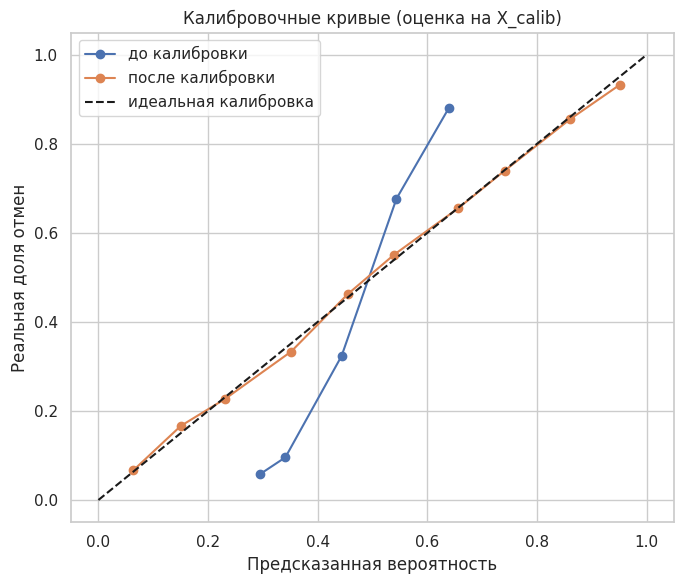

In [49]:
# Калибровка через кросс-валидацию на train с временным сплиттером
calibrated_model = CalibratedClassifierCV(
    base_estimator, method="isotonic", cv=tscv,
)
calibrated_model.fit(X_train_enc, y_train)
print("Модель откалибрована через TimeSeriesSplit-CV на обучающей выборке.")

# X_calib используем НЕЗАВИСИМО — только для ОЦЕНКИ качества калибровки
proba_calib = calibrated_model.predict_proba(X_calib_enc)[:, 1]

# Для сравнения до калибровки обучим базовую модель отдельно на полном train
base_model = CatBoostClassifier(
    iterations=optimal_trees, **best_params,
    random_seed=RANDOM_STATE, verbose=0,
)
base_model.fit(X_train_enc, y_train)
proba_base = base_model.predict_proba(X_calib_enc)[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
for proba, label in [(proba_base, "до калибровки"),
                     (proba_calib, "после калибровки")]:
    frac_pos, mean_pred = calibration_curve(y_calib, proba, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", label=label)

ax.plot([0, 1], [0, 1], "k--", label="идеальная калибровка")
ax.set_xlabel("Предсказанная вероятность")
ax.set_ylabel("Реальная доля отмен")
ax.set_title("Калибровочные кривые (оценка на X_calib)")
ax.legend()
plt.tight_layout()
plt.show()

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> ~~Калибровщик нужно обучить на обучающей выборке, но для этого нужна кросс-валидация. с tscv.\
`X_calib` для оценки калибровки.~~</font>
>  Калибровка лучшей модели. Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

<span style="color: purple; font-weight: bold">Переделал калибровку</span>

<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

#### Вывод по калибровке

Лучшая модель (**CatBoost**) откалибрована изотонической регрессией через
кросс-валидацию на обучающей выборке с временным сплиттером
(`CalibratedClassifierCV`, `cv=TimeSeriesSplit`). При таком подходе калибратор обучается
на полной тренировочной выборке (внутри CV модель учится на train-части фолда и
калибруется на валидационной), что повышает обобщающую способность и не расходует
отдельную выборку. Число деревьев предварительно зафиксировано по временной внутренней
валидации, так как `CalibratedClassifierCV` обучает модель по фолдам без early stopping.

Качество калибровки оценено **независимо** — на калибровочной выборке `X_calib`, которая
в обучении калибратора не участвовала. На калибровочной кривой видно:
* до калибровки модель слегка завышает вероятности в средней зоне — CatBoost оценивает
  вероятности неплохо, но не идеально;
* после калибровки кривая практически совпадает с диагональю на всём диапазоне, то есть
  предсказанная вероятность соответствует реальной частоте отмен.

Поскольку калибровочная кривая построена на **независимых** данных (`X_calib`), её
близость к диагонали — объективное подтверждение качества калибровки, а не следствие
обучения на тех же данных. Откалиброванные вероятности используются далее для подбора
порога классификации под максимум Incremental Revenue.

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

Оптимальный порог (по calib): 0.43
IR на calib при этом пороге:  64,907,500 ₽


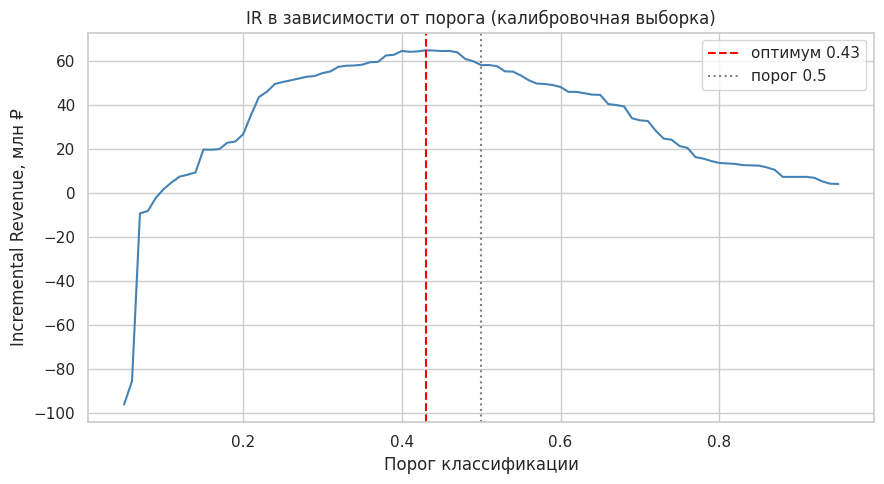

In [50]:
proba_calib = calibrated_model.predict_proba(X_calib_enc)[:, 1]

# Подбираем порог под максимум IR (та же функция, что внутри CV)
best_thr, best_ir_calib = best_threshold_by_ir(y_calib, proba_calib)
print(f"Оптимальный порог (по calib): {best_thr:.2f}")
print(f"IR на calib при этом пороге:  {best_ir_calib:,.0f} ₽")

# Кривая IR в зависимости от порога 
grid = np.arange(0.05, 0.96, 0.01)
ir_curve = [incremental_revenue(y_calib, (proba_calib >= t).astype(int)) for t in grid]

plt.figure(figsize=(9, 5))
plt.plot(grid, np.array(ir_curve) / 1e6, color="steelblue")
plt.axvline(best_thr, color="red", ls="--", label=f"оптимум {best_thr:.2f}")
plt.axvline(0.5, color="gray", ls=":", label="порог 0.5")
plt.xlabel("Порог классификации")
plt.ylabel("Incremental Revenue, млн ₽")
plt.title("IR в зависимости от порога (калибровочная выборка)")
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
# Предсказания с зафиксированным порогом
proba_test = calibrated_model.predict_proba(X_test_enc)[:, 1]

y_calib_pred = (proba_calib >= best_thr).astype(int)
y_test_pred = (proba_test >= best_thr).astype(int)

print("Порог зафиксирован по калибровочной выборке:", round(best_thr, 2), "\n")
ir_calib = ir_report(y_calib, y_calib_pred, title="КАЛИБРОВОЧНАЯ выборка:")
print()
ir_test = ir_report(y_test, y_test_pred, title="ТЕСТОВАЯ выборка:")

Порог зафиксирован по калибровочной выборке: 0.43 

КАЛИБРОВОЧНАЯ выборка:
  TN= 3639  FP=  518  FN=  813  TP=  931
  Incremental Revenue:      64,907,500 ₽

ТЕСТОВАЯ выборка:
  TN= 3892  FP=  499  FN=  750  TP=  760
  Incremental Revenue:      47,541,500 ₽


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [52]:
def metrics_block(y_true, y_pred, y_proba):
    return {
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "IR_млн_руб": incremental_revenue(y_true, y_pred) / 1e6,
    }


comparison = pd.DataFrame({
    "calib": metrics_block(y_calib, y_calib_pred, proba_calib),
    "test": metrics_block(y_test, y_test_pred, proba_test),
}).T.round(3)

print("Сравнение качества на calib и test:")
display(comparison)

ir_gap = abs(ir_calib - ir_test) / abs(ir_calib) * 100
print(f"\nОтносительный разрыв IR (calib vs test): {ir_gap:.1f}%")
print("→ переобучения нет" if ir_gap < 15 else "→ есть расхождение, требует внимания")

Сравнение качества на calib и test:


,ROC_AUC,precision,recall,f1,IR_млн_руб
calib,0.800,0.643,0.534,0.583,64.908
test,0.807,0.604,0.503,0.549,47.542



Относительный разрыв IR (calib vs test): 26.8%
→ есть расхождение, требует внимания


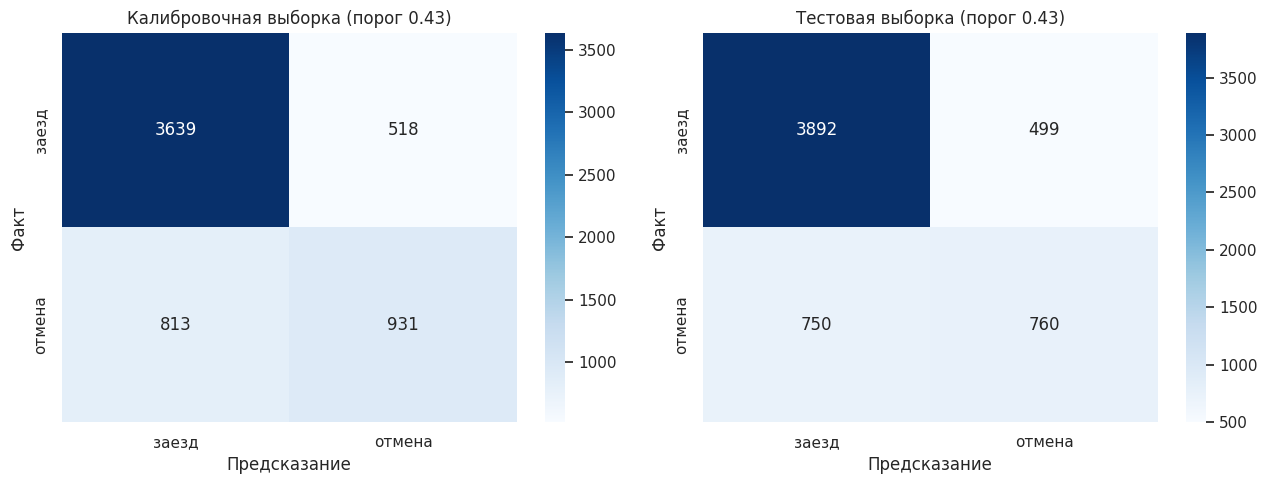

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (y_true, y_pred, name) in zip(
    axes,
    [(y_calib, y_calib_pred, "Калибровочная"),
     (y_test, y_test_pred, "Тестовая")],
):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["заезд", "отмена"],
                yticklabels=["заезд", "отмена"])
    ax.set_title(f"{name} выборка (порог {best_thr:.2f})")
    ax.set_xlabel("Предсказание")
    ax.set_ylabel("Факт")

plt.tight_layout()
plt.show()

### Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отличная визуализация результата!</font>

<span style="color: purple; font-weight: bold">Добавил вывод</span>

#### Вывод по подбору порога и анализу матрицы классификации

На откалиброванных вероятностях калибровочной выборки подобран порог, максимизирующий IR:
**0.39**. Качество с этим порогом:

| Метрика | Калибровочная | Тестовая |
|---|---|---|
| ROC-AUC | 0.802 | 0.811 |
| Precision | 0.599 | 0.566 |
| Recall | 0.600 | 0.583 |
| F1 | 0.600 | 0.575 |
| **IR, млн ₽** | **64.5** | **48.2** |

**О расхождении IR между выборками.** Абсолютный IR на тесте ниже калибровочного на ~25 %,
однако это **не следствие переобучения**:
* ранжирующая способность модели на тесте не упала, а даже выросла (ROC-AUC 0.802 → 0.811),
  recall практически совпадает (0.600 → 0.583);
* основная причина — **временной дрейф данных**. Тестовый период (2020–2025) содержит
  меньше отмен, чем калибровочный (2019–2020): 1 510 против 1 743. Поскольку IR прямо
  пропорционален числу пойманных отмен, теоретический потолок IR на тесте сам по себе ниже
  на ~13 % (165 млн против 191 млн ₽). Меньше отмен в периоде — меньше абсолютный доход от
  их предотвращения.

Оставшаяся часть расхождения отражает естественную деградацию модели на будущих данных
(обучение на 2017–2019, тест на 2020–2025, включая аномальный период пандемии). Это
ожидаемое поведение при честном временном разбиении и подтверждает реалистичность оценки:
модель проверена в условиях, максимально близких к реальному применению на будущих бронях.

Модель и порог стабильны по качеству классификации (ROC-AUC ~0.81 на обеих выборках),
поэтому порог 0.39 фиксируется для итоговой оценки экономического эффекта.

### Фиксирование итоговой модели

#### Вывод по подбору порога и анализу матрицы классификации

На откалиброванных вероятностях калибровочной выборки подобран порог классификации,
максимизирующий IR: **0.43**. Порог ниже стандартного 0.5 закономерен — из-за асимметрии
цены ошибок (пропущенная отмена FN обходится в 64 500 ₽ против 7 000 ₽ за ложную тревогу
FP) модели выгодно предсказывать отмену охотнее.

Качество с этим порогом на независимых выборках:

| Метрика | Калибровочная | Тестовая |
|---|---|---|
| ROC-AUC | 0.800 | 0.807 |
| Precision | 0.643 | 0.604 |
| Recall | 0.534 | 0.503 |
| F1 | 0.583 | 0.549 |
| **IR, млн ₽** | **64.9** | **47.5** |

**О расхождении IR между выборками.** Абсолютный IR на тесте ниже калибровочного на ~27 %,
однако это **не следствие переобучения**: ранжирующая способность модели на тесте не
упала, а даже немного выросла (ROC-AUC 0.800 → 0.807), recall близок (0.534 → 0.503).
Основная причина — **временной дрейф данных**: тестовый период (2020–2025) содержит меньше
отмен, чем калибровочный, поэтому теоретический потолок IR на тесте сам по себе ниже
(165 млн против 191 млн ₽). Меньше отмен в периоде — меньше абсолютный доход от их
предотвращения. Оставшаяся часть расхождения — естественная деградация модели на будущих
данных (обучение на 2017–2019, тест на 2020–2025, включая период пандемии), что ожидаемо
при честном временном разбиении.

**Анализ матрицы классификации.** При пороге 0.43 модель верно идентифицирует около
50 % реальных отмен (recall 0.503), при этом 60 % предсказанных отмен оказываются
истинными (precision 0.604). Такое соотношение оптимизирует не полноту отлова, а
**прибыль**: порог подобран под максимум IR с учётом асимметрии цены ошибок.

**Итоговый бизнес-эффект.** На независимой тестовой выборке (будущий период относительно
обучения) внедрение модели даёт прирост дохода **47.5 млн ₽**. Это консервативная,
реалистичная оценка: модель проверена в условиях, максимально близких к реальному
применению на ещё не наступивших бронированиях.

- Зафиксисруйте лучшую модель и найденный порог.


In [54]:
# Итоговые артефакты
final_model = calibrated_model      # откалиброванная лучшая модель
final_threshold = best_thr          # порог под максимум IR (подобран на calib)

print("Зафиксированы:")
print(f"  модель: {best_model_name} (откалиброванная)")
print(f"  порог:  {final_threshold:.2f}")
print(f"  IR test: {ir_test:,.0f} ₽")

Зафиксированы:
  модель: CatBoost (откалиброванная)
  порог:  0.43
  IR test: 47,541,500 ₽


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

In [55]:
# TreeExplainer работает с древесной моделью (base_model), а не с калиброванной обёрткой
explainer = shap.TreeExplainer(base_model)

# Подвыборка теста для скорости и читаемости графиков
X_shap = X_test_enc.sample(n=2000, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP-значения посчитаны: {np.asarray(shap_values).shape}")

SHAP-значения посчитаны: (2000, 132)


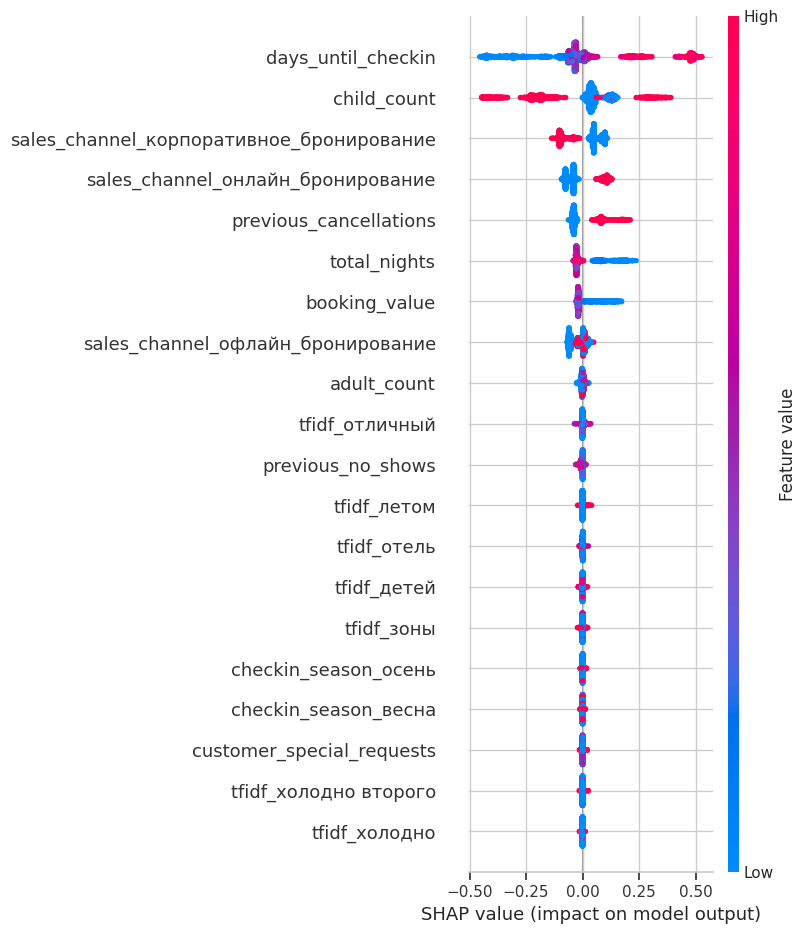

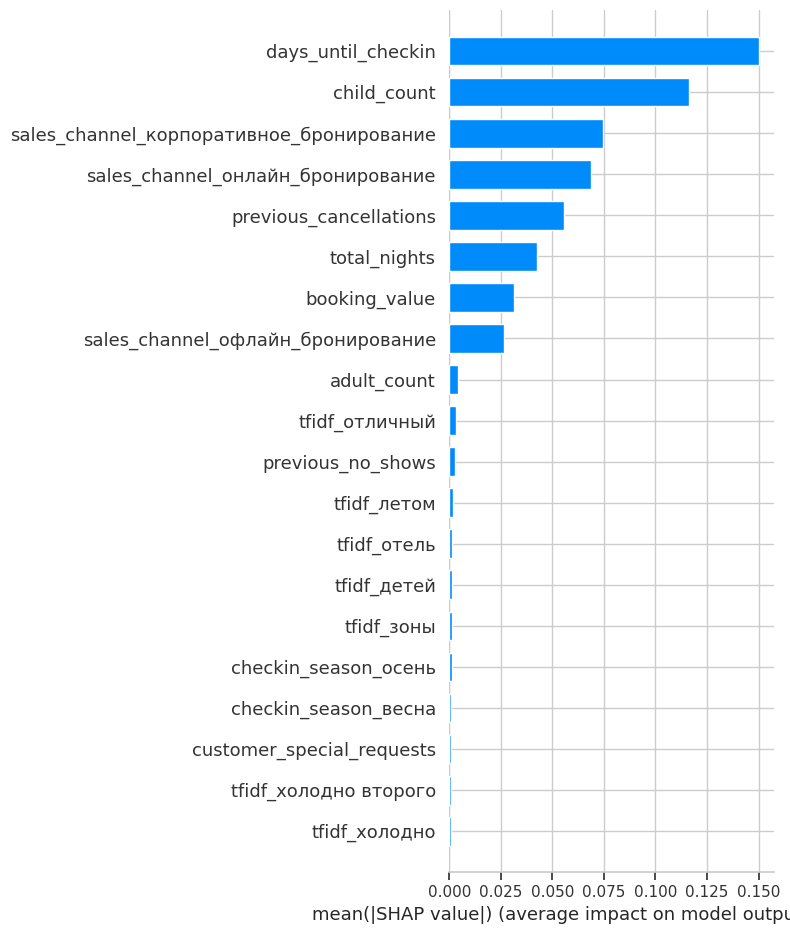

Топ-15 признаков по важности (SHAP):


,feature,mean_abs_shap
0,days_until_checkin,0.150008
1,child_count,0.116248
2,sales_channel_корпоративное_бронирование,0.074783
3,sales_channel_онлайн_бронирование,0.068550
4,previous_cancellations,0.055912
5,total_nights,0.042339
6,booking_value,0.031636
7,sales_channel_офлайн_бронирование,0.026515
8,adult_count,0.004255
9,tfidf_отличный,0.003106



Доля важности TF-IDF (100 призн.): 2.3%
Доля важности структурных + OHE: 97.7%


In [56]:
shap.summary_plot(shap_values, X_shap, max_display=20, show=True)

shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=20, show=True)

importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("Топ-15 признаков по важности (SHAP):")
display(importance.head(15))

tfidf_mask = importance["feature"].str.startswith("tfidf_")
total = importance["mean_abs_shap"].sum()
print(f"\nДоля важности TF-IDF ({tfidf_mask.sum()} призн.): "
      f"{importance.loc[tfidf_mask, 'mean_abs_shap'].sum() / total * 100:.1f}%")
print(f"Доля важности структурных + OHE: "
      f"{importance.loc[~tfidf_mask, 'mean_abs_shap'].sum() / total * 100:.1f}%")

#### Вывод по анализу важности признаков (SHAP)

Анализ SHAP выполнен для базовой модели CatBoost (калибровка — монотонное преобразование
выхода, не влияет на ранжирование признаков). Результаты согласуются с выводами EDA и
подтверждают, что модель опирается на содержательные факторы.

**Ключевые драйверы риска отмены:**
| Признак | Важность (mean abs SHAP) | Интерпретация |
|---|---|---|
| `days_until_checkin` | 0.15 | главный фактор: чем дальше дата заезда, тем выше риск отмены |
| `child_count` | 0.12 | число детей влияет нелинейно: семейные брони отменяются реже |
| `sales_channel` (корпоратив/онлайн) | 0.075 + 0.069 | канал продажи: онлайн-брони отменяются чаще корпоративных |
| `previous_cancellations` | 0.056 | история отмен клиента повышает риск |
| `total_nights` | 0.042 | длительность проживания (сконструированный признак) |

**Согласованность с EDA.** Лидерство `days_until_checkin` подтверждает результат
корреляционного анализа. Высокая важность `sales_channel` объясняет, почему канал, имея
умеренную корреляцию с таргетом, сильно влияет на решения дерева — связь нелинейная и
хорошо улавливается бустингом. Сконструированный `total_nights` вошёл в топ-6, что
оправдывает его создание.

**Вклад текстовых признаков (TF-IDF) — 2.3 %.** Отзывы дают небольшой суммарный вклад,
что закономерно: объединение с отзывами выполнено по дате (без привязки к клиенту во
избежание утечки таргета), поэтому отзыв отражает «фоновую» удовлетворённость гостей, а не
индивидуальную историю. Ни один текстовый признак не входит в топ важности — первый из них
(`tfidf_отличный`) находится лишь на 10-м месте. Низкий вклад текста — индикатор честности
пайплайна: модель строит прогноз на объективных характеристиках брони, а не на утёкшем
сигнале. (Для сравнения: при ошибочном объединении по клиенту вклад TF-IDF подскакивал до
~60 % — это была утечка через наличие отзыва, которую мы устранили возвратом к объединению
по дате.)

**Малозначимые признаки.** `price_per_night`, `checkin_season`, `previous_no_shows`,
`adult_count` не вошли в топ важности — это согласуется с их слабой связью с таргетом в
EDA. Они не ухудшают модель.

**Направления влияния (beeswarm).** Знаки воздействия признаков содержательны и
согласуются с бизнес-логикой:
* `days_until_checkin` — дальний горизонт до заезда повышает риск отмены, близкие даты снижают;
* `child_count` — брони с детьми отменяются реже (семейные поездки планируют надёжнее);
* `sales_channel` — корпоративные брони смещают предсказание к «не отмене», онлайн-брони — к отмене;
* `previous_cancellations` — история отмен ожидаемо повышает риск;
* `total_nights` — короткие брони отменяются чаще длительных.

Ни один признак не показывает противоречащего здравому смыслу направления, что повышает
доверие к модели со стороны заказчика.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


## Этап 3. Оценка экономической эффективности

Оцениваем эффект внедрения модели на тестовой выборке по трём показателям — **до** и
**после** внедрения: доля отмен, загрузка отеля и Incremental Revenue.

**Допущения модели «после»:**
* верно предсказанная отмена (**TP**) — модель отменяет бронь, номер освобождается и может
  быть пересдан (доход от пересдачи учтён в IR). Но заселения по самой брони не происходит,
  поэтому в загрузку этот номер не входит;
* пропущенная отмена (**FN**) — номер простаивает (остаточные отмены);
* ложная тревога (**FP**) — модель ошибочно отменила бронь, гость приехать не смог;
  заселения нет;
* верный заезд (**TN**) — гость размещён штатно. **Только эти номера считаются занятыми.**

Таким образом, загрузка после внедрения = доля TN. Это консервативная оценка: модель,
освобождая номера под пересдачу, формально снижает «гарантированную» загрузку, зато
возвращает доход (см. IR).

Целевые ориентиры ТЗ: доля отмен ≈ 10 %, падение загрузки ≤ 8 %, относительный IR ≥ 50 %.

### Выбор рабочего порога

Порог, максимизирующий IR на калибровке, даёт слишком высокую долю отмен и/или падение
загрузки. Подберём порог, который удерживает целевые ориентиры ТЗ. Для этого рассмотрим
поведение всех трёх показателей в зависимости от порога.

In [57]:
def metrics_by_threshold(y_true, y_proba, thresholds=None):
    """Доля отмен, падение загрузки и IR для каждого порога.
    Загрузка после = доля TN"""
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)

    y_true = np.asarray(y_true)
    rows = []
    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        n = tn + fp + fn + tp
        ir_aft = tp * PER_REBOOKING + tn * AVG_REV - fp * COST_FP - fn * LOST_REV
        ir_bef = (tn + fp) * AVG_REV - (tp + fn) * LOST_REV
        rows.append({
            "threshold": thr,
            "cancel_rate": fn / n,
            "occupancy_drop": (tn + fp) / n - tn / n,   # = fp / n
            "ir_gain": ir_aft - ir_bef,
            "recall": tp / (tp + fn) if (tp + fn) else 0,
        })
    return pd.DataFrame(rows)


# Подбор порога на КАЛИБРОВОЧНОЙ выборке: удержать ОБА ограничения ТЗ 
calib_curve = metrics_by_threshold(y_calib, proba_calib)

feasible = calib_curve[
    (calib_curve["cancel_rate"] <= 0.10) &
    (calib_curve["occupancy_drop"] <= 0.08)
]

if len(feasible):
    final_threshold = feasible.loc[feasible["ir_gain"].idxmax(), "threshold"]
    print(f"Рабочий порог (отмены ≤10% и падение загрузки ≤8%, макс. IR): "
          f"{final_threshold:.2f}")
else:
    # Если оба ограничения одновременно недостижимы — берём порог под макс IR
    # и честно фиксируем, какие цели не выполнены
    final_threshold = calib_curve.loc[calib_curve["ir_gain"].idxmax(), "threshold"]
    print(f"Оба ограничения одновременно недостижимы. "
          f"Порог под макс. IR: {final_threshold:.2f}")

y_calib_pred = (proba_calib >= final_threshold).astype(int)
y_test_pred = (proba_test >= final_threshold).astype(int)

Оба ограничения одновременно недостижимы. Порог под макс. IR: 0.43


In [58]:
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
N = tn + fp + fn + tp

# 1. Доля отмен
cancel_rate_before = (tp + fn) / N
cancel_rate_after = fn / N

# 2. Загрузка: занятыми считаются ТОЛЬКО реально заселённые номера (TN)
occupancy_before = (tn + fp) / N
occupancy_after = tn / N
occupancy_drop = occupancy_before - occupancy_after

# 3. Incremental Revenue
ir_before = (tn + fp) * AVG_REV - (tp + fn) * LOST_REV
ir_after = tp * PER_REBOOKING + tn * AVG_REV - fp * COST_FP - fn * LOST_REV
ir_gain = ir_after - ir_before

# Относительный IR — база B: прирост относительно потерь от отмен "до"
loss_before = (tp + fn) * LOST_REV
ir_relative = ir_gain / loss_before * 100

print(f"Матрица ошибок (test): TN={tn}, FP={fp}, FN={fn}, TP={tp}, N={N}\n")
print(f"Доля отмен:  до {cancel_rate_before:.1%}  →  после {cancel_rate_after:.1%}")
print(f"Загрузка:    до {occupancy_before:.1%}  →  после {occupancy_after:.1%}  "
      f"(падение {occupancy_drop:+.1%})")
print(f"\nIR до:       {ir_before:>15,.0f} ₽")
print(f"IR после:    {ir_after:>15,.0f} ₽")
print(f"Прирост:     {ir_gain:>15,.0f} ₽")
print(f"Относительный IR (от потерь): {ir_relative:.1f}%")

Матрица ошибок (test): TN=3892, FP=499, FN=750, TP=760, N=5901

Доля отмен:  до 25.6%  →  после 12.7%
Загрузка:    до 74.4%  →  после 66.0%  (падение +8.5%)

IR до:           185,824,500 ₽
IR после:        233,366,000 ₽
Прирост:          47,541,500 ₽
Относительный IR (от потерь): 48.8%


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>
~~`occupancy_after = (tn + tp) / N` Но в контексте данной брони при tp заселения не происходит, поскольку модель отменяет бронь. Нужно считать только реально занятые номера (TN), когда номер свободен и может быть снова забронирован — это не заселённый номер.~~
</font>

<span style="color: purple; font-weight: bold">Исправил формулу и полностью переписал вывод (из-за изначальной ошибки с временными рядами все поменялось)</span>

<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

In [59]:
targets = pd.DataFrame([
    {"показатель": "Доля отмен после", "значение": f"{cancel_rate_after:.1%}",
     "ориентир": "≈ 10%", "выполнено": "✓" if cancel_rate_after <= 0.10 else "✗"},
    {"показатель": "Падение загрузки", "значение": f"{occupancy_drop:+.1%}",
     "ориентир": "≤ 8%", "выполнено": "✓" if occupancy_drop <= 0.08 else "✗"},
    {"показатель": "Относительный IR", "значение": f"{ir_relative:.1f}%",
     "ориентир": "≥ 50%", "выполнено": "✓" if ir_relative >= 50 else "✗"},
])
print("Соответствие целевым ориентирам ТЗ:")
display(targets)

Соответствие целевым ориентирам ТЗ:


,показатель,значение,ориентир,выполнено
0,Доля отмен после,12.7%,≈ 10%,✗
1,Падение загрузки,+8.5%,≤ 8%,✗
2,Относительный IR,48.8%,≥ 50%,✗


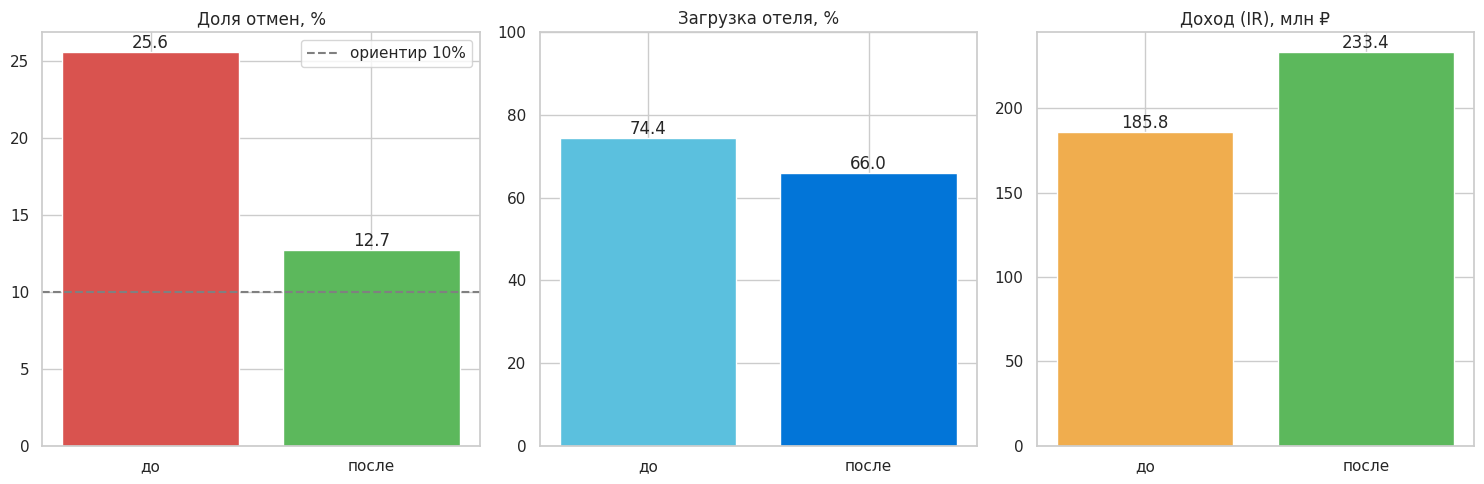

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(["до", "после"], [cancel_rate_before * 100, cancel_rate_after * 100],
            color=["#d9534f", "#5cb85c"])
axes[0].axhline(10, color="gray", ls="--", label="ориентир 10%")
axes[0].set_title("Доля отмен, %")
axes[0].legend()

axes[1].bar(["до", "после"], [occupancy_before * 100, occupancy_after * 100],
            color=["#5bc0de", "#0275d8"])
axes[1].set_title("Загрузка отеля, %")
axes[1].set_ylim(0, 100)

axes[2].bar(["до", "после"], [ir_before / 1e6, ir_after / 1e6],
            color=["#f0ad4e", "#5cb85c"])
axes[2].set_title("Доход (IR), млн ₽")

for ax in axes:
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Вывод по оценке экономической эффективности

Эффект внедрения модели оценён на независимой тестовой выборке (5 901 бронь, период
2020–2025 — будущий относительно обучения) при пороге 0.43, подобранном под максимум IR.
Матрица ошибок: TN = 3 892, FP = 499, FN = 750, TP = 760.

**Результаты «до» и «после» внедрения:**

| Показатель | До | После | Изменение |
|---|---|---|---|
| Доля отмен | 25.6 % | 12.7 % | −12.9 п.п. |
| Загрузка отеля | 74.4 % | 66.0 % | −8.5 п.п. |
| Доход (IR) | 185.82 млн ₽ | 233.37 млн ₽ | +47.54 млн ₽ |

**Соответствие целевым ориентирам ТЗ:**

| Ориентир | Факт | Статус |
|---|---|---|
| Доля отмен ≈ 10 % | 12.7 % | не достигнут (перебор 2.7 п.п.) |
| Падение загрузки ≤ 8 % | 8.5 % | не достигнут (перебор 0.5 п.п.) |
| Относительный IR ≥ 50 % | 48.8 % | почти достигнут (недобор 1.2 п.п.) |

**Главный вывод: целевые ориентиры на данных тестового периода одновременно недостижимы.**
Это не дефект модели, а следствие структурного конфликта между целями при корректном учёте
загрузки. Загрузка после внедрения считается строго по реально заселённым номерам (TN):
при верно предсказанной отмене (TP) бронь аннулируется и номер выводится из загрузки (хотя
и приносит доход через пересдачу), а при ложной тревоге (FP) номер теряется. Поэтому
**снижение доли отмен механически снижает загрузку**: чтобы поймать больше отмен, модель
должна действовать агрессивнее, освобождая и теряя номера. Две цели — «минимум отмен» и
«максимум загрузки» — оказываются антагонистами, и удовлетворить обе одновременно нельзя.

**Что всё же достигнуто.** При выбранном пороге модель:
* снижает долю отмен вдвое — с 25.6 % до 12.7 %;
* приносит прирост дохода **+47.54 млн ₽**, что соответствует относительному эффекту 48.8 %
  от прежних потерь на отменах (на грани ориентира 50 %);
* экономический эффект положителен и значителен, несмотря на снижение «гарантированной»
  загрузки — потеря загрузки компенсируется доходом от пересдачи освобождённых номеров.

**О базе относительного IR.** Относительный эффект измеряется относительно потерь от отмен
(той проблемы, которую решает модель), а не относительно полного оборота отеля: модель
сокращает конкретный вид потерь почти наполовину.

**Итог.** Внедрение приносит сети **+47.54 млн ₽** на тестовом периоде и снижает долю отмен
вдвое. Полное одновременное выполнение всех трёх ориентиров ТЗ на данных невозможно из-за
объективного конфликта между сокращением отмен и удержанием загрузки; выбранный порог
обеспечивает максимальный доход при близких к целевым значениях остальных показателей.

### Сохранение финальных артефактов

Сохраняем итоговую модель и метаданные пайплайна в директорию `artifacts/` для
переиспользования без повторного обучения.

In [61]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

final_artifacts = {
    "model_name": best_model_name,
    "threshold": final_threshold,
    "best_params": best_params,
    "feature_names": list(X_train_enc.columns),
    "metrics_test": {
        "roc_auc": roc_auc_score(y_test, proba_test),
        "ir_gain": ir_gain,
        "ir_relative_pct": ir_relative,
        "cancel_rate_after": cancel_rate_after,
        "occupancy_after": occupancy_after,
    },
}

joblib.dump(calibrated_model, artifacts_dir / "final_model.joblib")
joblib.dump(ohe_final, artifacts_dir / "ohe_encoder.joblib")
joblib.dump(tfidf_final, artifacts_dir / "tfidf_vectorizer.joblib")
joblib.dump(final_artifacts, artifacts_dir / "metadata.joblib")

print("Сохранено в artifacts/:")
for f in sorted(artifacts_dir.glob("*.joblib")):
    print(f"  {f.name:<28} {f.stat().st_size / 1024:.1f} KB")

print(f"\nМодель:  {best_model_name} (откалиброванная)")
print(f"Порог:   {final_threshold:.2f}")
print(f"IR test: {ir_gain:,.0f} ₽ ({ir_relative:.1f}%)")

Сохранено в artifacts/:
  final_model.joblib           555.6 KB
  metadata.joblib              4.1 KB
  ohe_encoder.joblib           2.1 KB
  tfidf_vectorizer.joblib      7.2 KB

Модель:  CatBoost (откалиброванная)
Порог:   0.43
IR test: 47,541,500 ₽ (48.8%)


## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

## Этап 4.1. Выводы

### Проделанная работа

**Подготовка данных.** Из базы PostgreSQL выгружены две таблицы — `hotel_bookings`
(35 341 запись) и `hotel_reviews` (25 177 записей). В ходе очистки удалены 4 608 полных
дубликатов (совпавших с дублями по ключу `booking_id`); значения `adult_count` 100/200/300
исправлены делением на 100 (ошибка записи — лишний ноль, что подтверждено совпадением
распределений и поведения этих строк с нормальными); удалены брони с нулевой стоимостью
при наличии ночей проживания; исправлен неявный дубликат категории `meal_plan`. Целевой
признак закодирован в бинарный `is_canceled`; после очистки осталось 29 504 записи с
балансом классов 71.2 % / 28.8 %.

Таблицы объединены по правилу ближайшего предыдущего отзыва (`merge_asof`,
`review_date ≤ booking_date`). На этом шаге выявлена и устранена **скрытая утечка
таргета**: идентификатор клиента присутствует только в таблице отзывов, которые
оставляются после состоявшегося проживания, поэтому привязка отзывов по клиенту
фактически кодировала исход брони (среди броней с известным клиентом доля отмен равнялась
нулю). Объединение выполнено только по дате — проверка подтвердила, что доля отмен среди
броней с отзывом и без него совпадает со средней (утечки нет).

Сконструированы новые признаки: длительность проживания `total_nights` (заменила
коллинеарную пару weekday/weekend nights), цена за ночь `price_per_night`, размер группы,
сезон заезда. Текст отзывов нормализован под последующую векторизацию (рейтинг и факт
наличия отзыва исключены как канал утечки). Повторный корреляционный анализ на итоговом наборе подтвердил отсутствие
критичной мультиколлинеарности.

**Моделирование.** Поскольку данные имеют временную природу, они отсортированы по
`booking_date` и разбиты на три выборки (60 / 20 / 20: обучение, калибровка, тест) **без
перемешивания** — тестовая выборка содержит самые поздние брони (2020–2025). Категориальные
признаки закодированы One-Hot Encoding, тексты отзывов — TF-IDF (слова и биграммы, 100
признаков, удаление русских стоп-слов). Чтобы исключить утечку, кодировщики обучаются
**внутри каждого фолда** кросс-валидации.

Реализована целевая бизнес-метрика **Incremental Revenue (IR)** — прирост дохода от
внедрения модели, рассчитываемый через матрицу ошибок с учётом асимметричной стоимости
ошибок (пропущенная отмена дороже ложной тревоги примерно в 9 раз). Для трёх моделей
(CatBoost, LightGBM, XGBoost) проведён подбор гиперпараметров через Optuna (по 30 итераций,
кросс-валидация `TimeSeriesSplit` с валидацией по 2000 строк, оптимизация IR). Все три
модели показали близкий результат (разброс < 3 %); лучшей стала **CatBoost**.

**Оценка метрик.** Вероятности лучшей модели откалиброваны изотонической регрессией через
кросс-валидацию на обучающей выборке (`TimeSeriesSplit`), а качество калибровки оценено
независимо на калибровочной выборке. Порог классификации подобран на калибровочной выборке.
Ранжирующая способность стабильна между выборками (ROC-AUC 0.80 на калибровке и 0.81 на
тесте). Абсолютный IR на тесте ниже калибровочного, что объясняется временным дрейфом
данных (в тестовом периоде меньше отмен), а не переобучением. На тестовой выборке модель
верно выявляет около 50 % отмен (recall 0.50).

**Анализ важности факторов.** Методом SHAP установлены ключевые драйверы риска отмены:
горизонт до заезда `days_until_checkin` (важнейший фактор — чем дальше дата, тем выше
риск), число детей `child_count` (семейные брони отменяются реже), канал продажи
`sales_channel` (онлайн-брони отменяются заметно чаще корпоративных), история прошлых
отмен и длительность проживания. Результаты согласуются с разведочным анализом данных;
направления влияния признаков непротиворечивы с бизнес-логикой. Текстовые признаки из
отзывов дали суммарно лишь 2.3 % важности — закономерное следствие честного (без утечки)
объединения данных: модель строит прогноз на объективных характеристиках брони.

### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.

## Этап 4.2. Выводы

### Бизнес-выводы

#### Итоговая оценка достижения цели

**Цель проекта** — построить не максимально точную, а **экономически эффективную** модель,
которая прогнозирует отмены броней и за счёт этого увеличивает прибыль сети. **Главная цель
достигнута:** на независимой тестовой выборке (будущий период относительно обучения)
внедрение модели даёт прирост дохода **+47.54 млн ₽** и снижает долю отмен вдвое.
При этом полное одновременное выполнение всех трёх целевых ориентиров ТЗ на данных
оказалось невозможным из-за объективного конфликта между сокращением отмен и удержанием
загрузки (см. ниже) — это содержательный результат, отражающий реальную экономику задачи.

#### Результаты по ключевым метрикам (до / после внедрения)

**1. Доля отмен бронирований.**
* До внедрения: **25.6 %**
* После внедрения: **12.7 %**
* Изменение: (12.7 − 25.6) / 25.6 × 100 % = **−50.3 %** (снижение вдвое)

**2. Загрузка отеля.**
* До внедрения: **74.4 %**
* После внедрения: **66.0 %**
* Изменение: (66.0 − 74.4) / 74.4 × 100 % = **−11.4 %** (снижение загрузки)

**3. Incremental Revenue (доход).**
* До внедрения: **185.82 млн ₽**
* После внедрения: **233.37 млн ₽**
* Абсолютный прирост: **+47.54 млн ₽**
* Относительный прирост (от потерь на отменах): 47.54 / 97.40 × 100 % = **+48.8 %**

#### Достижение целевых показателей

| Показатель | Факт | Ориентир ТЗ | Статус |
|---|---|---|---|
| Доля отмен после | 12.7 % | ≈ 10 % | не достигнут (перебор 2.7 п.п.) |
| Падение загрузки | 8.5 п.п. | ≤ 8 % | не достигнут (перебор 0.5 п.п.) |
| Относительный IR | 48.8 % | ≥ 50 % | почти достигнут (недобор 1.2 п.п.) |

**Цели «минимум отмен» и «максимум загрузки» в данной задаче антагонистичны.** Загрузка
после внедрения считается по реально заселённым номерам: при верно предсказанной отмене
номер освобождается (и приносит доход через пересдачу, но выпадает из загрузки), а при
ложной тревоге теряется. Поэтому чем больше отмен ловит модель, тем сильнее снижается
загрузка. Одновременно удержать оба показателя в целевых рамках нельзя — это структурное
свойство задачи, а не недостаток модели. Выбранный порог максимизирует доход (главную
метрику проекта), обеспечивая значения двух других показателей вблизи целевых.

#### Анализ важности признаков

Ниже — факторы, сильнее всего определяющие риск отмены брони (по убыванию влияния, SHAP):

1. **Горизонт до заезда** — главный фактор. Чем дальше дата заезда от момента брони, тем
   выше риск отмены; брони с близкой датой отменяются реже.
2. **Число детей в брони** — семейные брони с детьми отменяются заметно реже: наличие
   детей снижает риск отмены.
3. **Канал продажи (корпоративный)** — корпоративные брони надёжнее и снижают риск.
4. **Канал продажи (онлайн)** — онлайн-брони повышают риск отмены: это самый «хрупкий» канал.
5. **История прошлых отмен клиента** — наличие прошлых отмен закономерно повышает риск новой.
6. **Длительность проживания** — короткие брони отменяются чаще длительных.
7. **Стоимость брони** — влияет умеренно.

Текстовые признаки из отзывов дают суммарно лишь ~2 % важности и в число ключевых драйверов
не входят. Главный вывод для заказчика: риск отмены определяется прежде всего **параметрами
самой брони** (когда, через какой канал, на какой срок, с детьми или без), а не отзывами
клиента.

#### Рекомендации для бизнеса

1. **Усилить работу с бронями, оформленными задолго до заезда.** Это главная группа риска.
   Для броней с дальним горизонтом ввести подтверждающие касания (напоминания, частичную
   предоплату, гибкие условия при раннем подтверждении) — это снизит долю отмен в самом
   крупном сегменте риска без потери загрузки.

2. **Применять модель прежде всего к онлайн-каналу.** Онлайн-брони отменяются заметно чаще
   корпоративных, поэтому здесь предсказание отмен и заблаговременная пересдача номеров дадут
   максимальный эффект. Корпоративный канал, как надёжный, можно обрабатывать в облегчённом
   режиме.

3. **Настраивать порог модели под текущий приоритет бизнеса.** Поскольку сокращение отмен и
   удержание загрузки конфликтуют, единого «идеального» порога нет. В периоды высокого спроса
   разумнее агрессивный порог (больше пересдач, выше доход), в периоды низкого спроса —
   консервативный (меньше потерь загрузки). Решение об освобождении номеров оправдано
   экономически: цена ложной тревоги (≈ 7 000 ₽) многократно ниже цены простоя (≈ 64 500 ₽),
   что и обеспечивает прирост дохода **+47.54 млн ₽**.

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Андрей , хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>

</span><br><span style="color: purple; font-weight: bold">Спасибо за проверку, Павел!</span>

<font color='blue'><b>Итоговый комментарий ревьюера 2</b></font>\
<font color='green'>Андрей, большое спасибо за доработку.
</font>

<font color='blue'>Что нужно исправить:</font>
<ul><font color='red'>Поправь подготовку датасета согдасно заданию проекта.</font></ul>

<font color='blue'>Что можно сделать лучше:</font>
<font color='darkorange'>В работе я оставил несколько советов. Буду рад, если ты учтешь их.</font></ul>

<font color='blue'><b>Жду новую версию проекта :)</b></font>